# DC Housing Market Analysis: Exploratory Data Analysis

## 1. Introduction and Setup

-   **Purpose**: This analysis explores the DC housing market and
    related economic indicators to understand market dynamics, identify
    key relationships, and prepare features for predictive modeling.
-   **Data**: Monthly economic and housing data for Washington DC from
    January 2000 to December 2024.
-   **Key Questions**:
    -   What factors influence DC housing prices?
    -   How have housing prices evolved through different economic
        cycles?
    -   Which variables lead or lag housing price changes?
    -   What features would be most valuable for forecasting?

In [34]:
# Import libraries (consolidate all imports here)
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from datetime import datetime
import os
import json
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import pickle

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Create directories for saving visualizations
os.makedirs('outputs/EDA', exist_ok=True)
print("Output directory set to: outputs/EDA")

Output directory set to: outputs/EDA


## 2. Data Loading and Initial Examination

### 2.1 Load and Prepare Data

In [35]:
# Load the processed dataset
df = pd.read_csv('dc_economic_quarterly_dataframe.csv')

# Convert Date column to datetime and set as index for time series analysis
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Display basic information
print(f"Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Time period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Duration: {((df.index.max() - df.index.min()).days / 365.25):.1f} years ({df.shape[0]} quarters)")

Dataset dimensions: 100 rows × 15 columns
Time period: January 2000 to October 2024
Duration: 24.8 years (100 quarters)


### 2.2 Data Dictionary

Create a data dictionary to clearly explain all variables:

| Variable                | Description                  | Unit                 | Source          |
|-------------------------|------------------------------|----------------------|-----------------|
| ZHVI                    | Zillow Home Value Index      | USD                  | Zillow          |
| Unemployment_Rate       | DC unemployment rate         | %                    | BLS             |
| CPI                     | Consumer Price Index         | Index (1982-84=100)  | BLS             |
| Interest_Rate           | Federal funds rate           | %                    | Federal Reserve |
| Mortgage_Rate           | 30-year fixed mortgage rate  | %                    | Freddie Mac     |
| GDP_Growth              | DC GDP quarterly growth rate | %                    | BEA             |
| Median_Household_Income | DC median household income   | USD                  | Census          |
| Population              | DC population                | Thousands            | Census          |
| Poverty_Rate            | DC poverty rate              | %                    | Census          |
| Marriage_Rate           | DC marriage rate             | Per 1,000 population | CDC             |
| Divorce_Rate            | DC divorce rate              | Per 1,000 population | CDC             |

### 2.3 Check for Missing Values and Data Quality

In [36]:
# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print("\nMissing values found in:")
    print(missing[missing > 0])
else:
    print("\nNo missing values in the dataset")

# Display the first few rows to verify data structure
df.head()


No missing values in the dataset


,Year,Quarter,Unemployment_Rate,CPI,Interest_Rate,Mortgage_Rate,ZHVI,GDP_Growth,Median_Household_Income,Population,Poverty_Rate,Marriage_Rate,Divorce_Rate,YearQuarter,QuarterLabel
Date,,,,,,,,,,,,,,,
2000-01-01,2000,1,5.70,171.50,5.68,8.26,179387.58,6.89,41716.56,572.05,17.50,4.08,3.25,2000-Q1,Q1 2000
2000-04-01,2000,2,5.60,173.00,6.27,8.32,181210.33,4.86,42580.81,572.05,17.50,5.55,3.04,2000-Q2,Q2 2000
2000-07-01,2000,3,5.67,174.90,6.52,8.03,185201.08,0.69,42521.31,572.05,17.50,5.88,3.25,2000-Q3,Q3 2000
2000-10-01,2000,4,5.80,175.35,6.47,7.64,189968.10,1.32,41830.81,572.05,17.50,4.08,3.25,2000-Q4,Q4 2000
2001-01-01,2001,1,6.00,176.55,5.59,7.01,194527.55,-0.38,40813.25,574.50,18.10,5.17,2.95,2001-Q1,Q1 2001


## 3. Descriptive Statistics and Distributions

### 3.1 Statistical Summary

In [37]:
# First, let's identify numeric columns only
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

# Generate comprehensive descriptive statistics only on numeric columns
desc_stats = df[numeric_columns].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).T

# Add additional statistics
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['coef_var'] = desc_stats['std'] / desc_stats['mean'] * 100  # Coefficient of variation
desc_stats['skewness'] = df[numeric_columns].skew()
desc_stats['kurtosis'] = df[numeric_columns].kurtosis()

# Display the enhanced statistics
print("Enhanced Descriptive Statistics (Quarterly Data):")
desc_stats = desc_stats[['count', 'mean', 'std', 'min', '10%', '25%', '50%', '75%', '90%', 'max', 'range', 'coef_var', 'skewness', 'kurtosis']]
display(desc_stats)

Enhanced Descriptive Statistics (Quarterly Data):


,count,mean,std,min,10%,25%,50%,75%,90%,max,range,coef_var,skewness,kurtosis
Year,100.00,2012.00,7.25,2000.00,2002.00,2006.00,2012.00,2018.00,2022.00,2024.00,24.00,0.36,0.00,-1.20
Quarter,100.00,2.50,1.12,1.00,1.00,1.75,2.50,3.25,4.00,4.00,3.00,44.95,0.00,-1.37
Unemployment_Rate,100.00,7.04,1.58,4.13,5.30,5.89,6.68,7.94,9.74,10.60,6.47,22.44,0.63,-0.43
CPI,100.00,238.06,38.41,171.50,184.84,208.28,242.76,261.86,296.72,316.91,145.41,16.14,0.13,-0.66
Interest_Rate,100.00,1.92,2.02,0.06,0.09,0.14,1.23,3.47,5.26,6.52,6.46,105.45,0.84,-0.72
Mortgage_Rate,100.00,5.15,1.39,2.76,3.51,3.92,5.01,6.26,6.97,8.32,5.56,26.99,0.21,-0.98
ZHVI,100.00,373171.07,96195.08,179387.58,234535.62,316991.89,374348.97,425684.58,527503.35,566134.56,386746.98,25.78,0.02,-0.33
GDP_Growth,100.00,2.31,4.43,-17.79,-0.09,1.31,2.38,3.56,4.74,32.97,50.76,191.38,2.15,27.08
Median_Household_Income,100.00,68180.48,22607.85,38782.42,42676.60,48957.00,61995.19,88007.85,105757.98,111000.00,72217.58,33.16,0.55,-0.94
Population,100.00,631.91,53.02,567.14,568.50,574.40,635.74,677.01,702.25,708.25,141.12,8.39,0.02,-1.69


### 3.2 Distribution Visualization

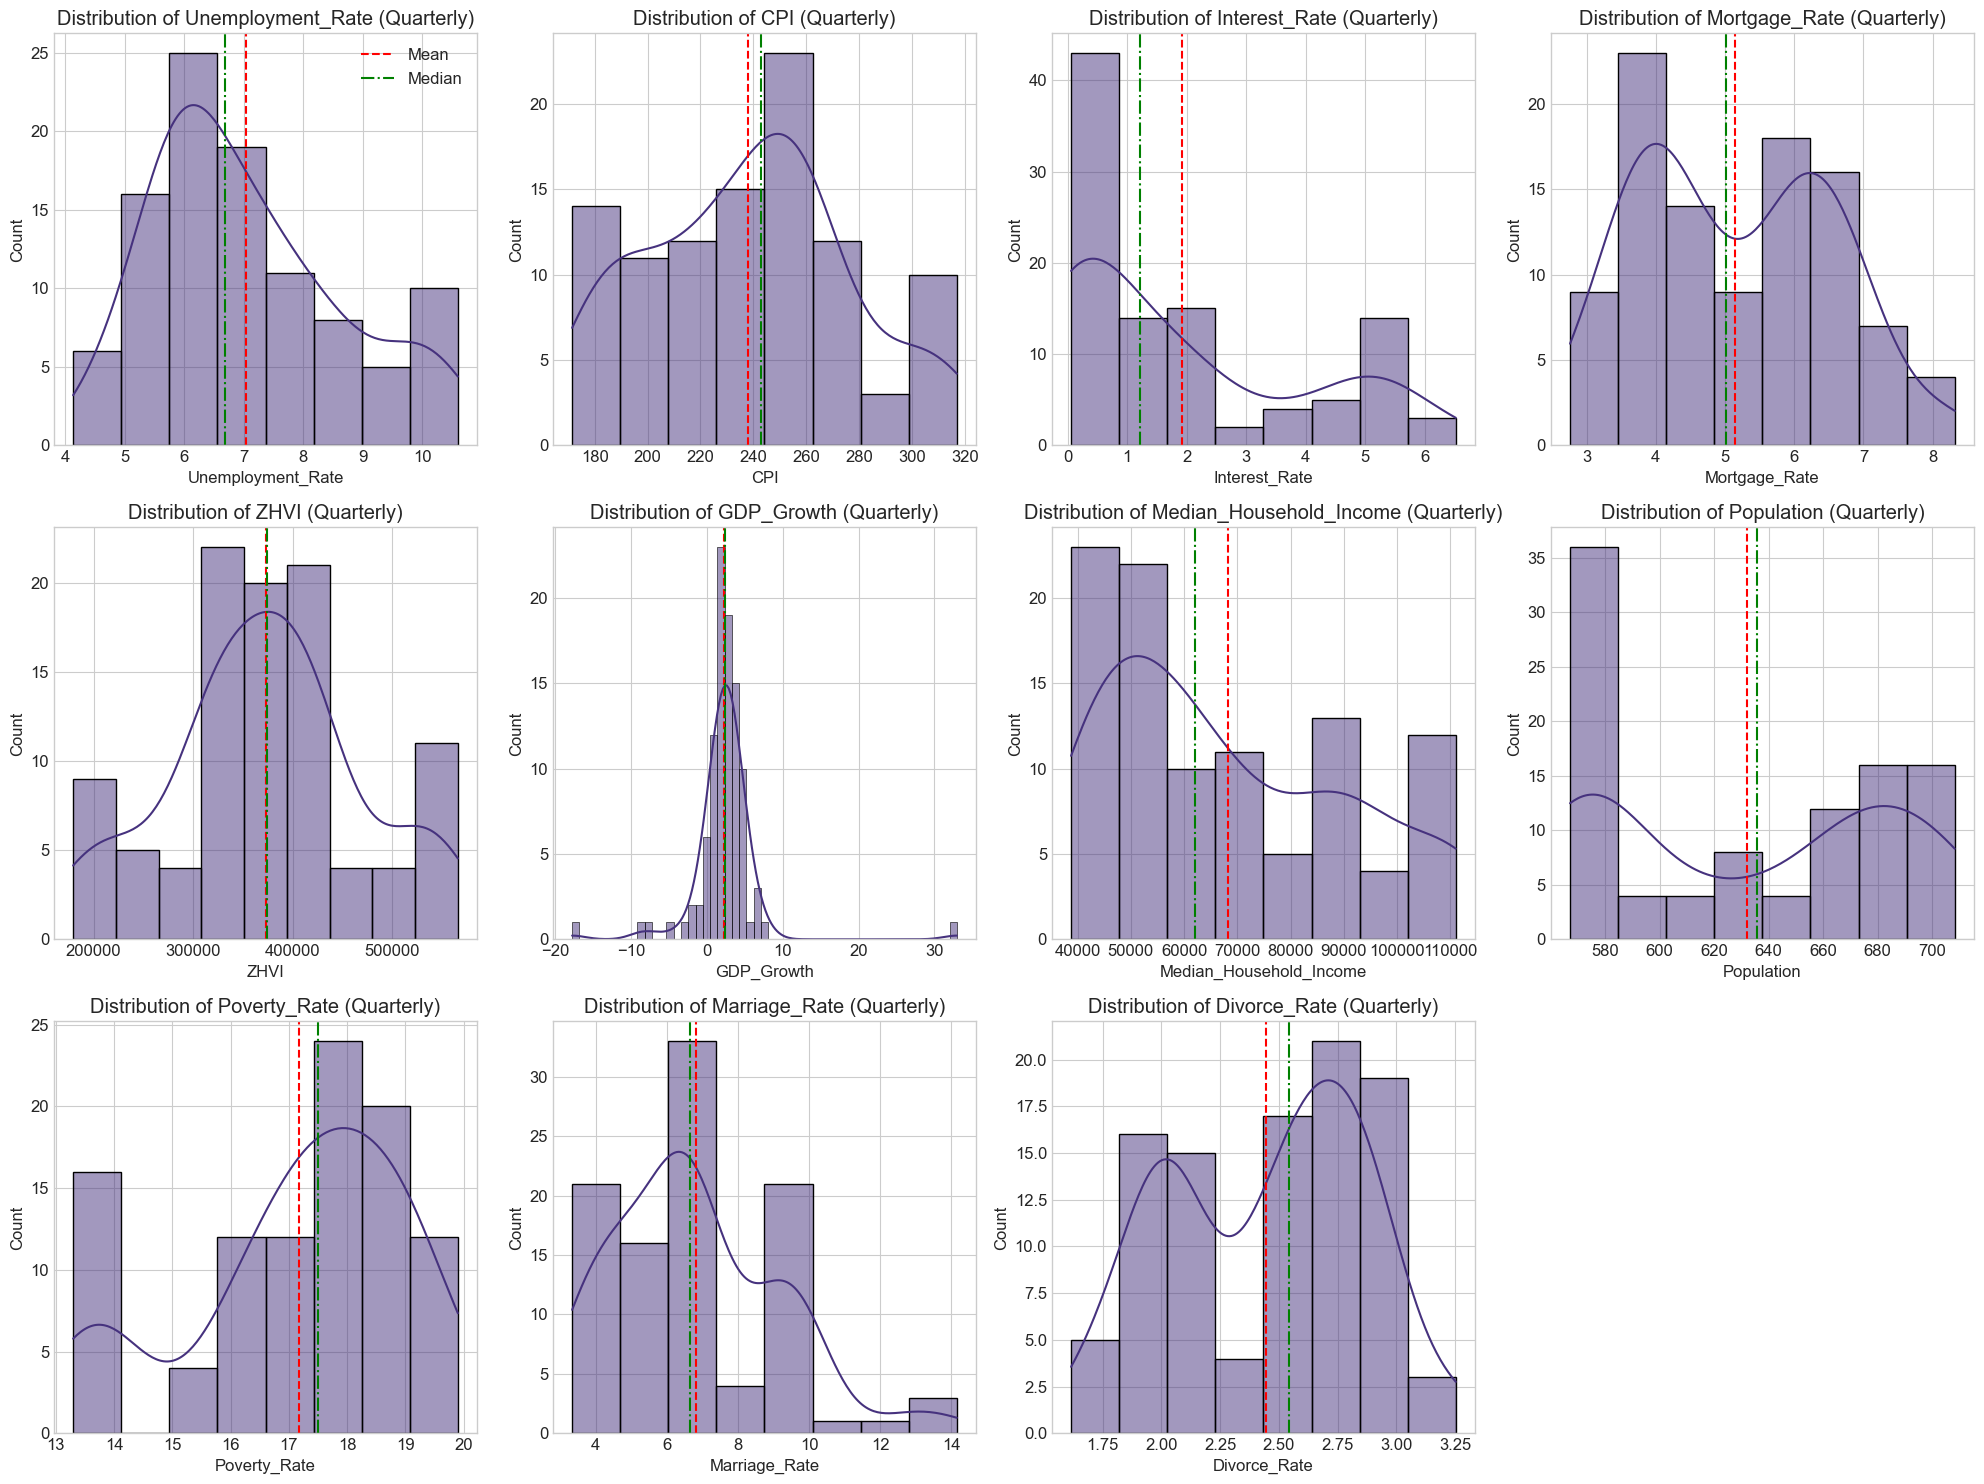

In [38]:
# Get only numeric columns for visualization
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

# Remove Year and Quarter columns if they exist
columns_to_plot = [col for col in numeric_columns if col not in ['Year', 'Quarter']]

# Create visualizations of distributions
fig, axs = plt.subplots(3, 4, figsize=(20, 15))
axs = axs.flatten()

for i, col in enumerate(columns_to_plot):
    if i < len(axs):
        # Create a density plot with histogram
        sns.histplot(df[col], kde=True, ax=axs[i])
        axs[i].set_title(f'Distribution of {col} (Quarterly)')
        
        # Add mean and median lines
        axs[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
        axs[i].axvline(df[col].median(), color='green', linestyle='-.', label='Median')
        
        # Add labels
        if i == 0:  # Only add legend to the first plot
            axs[i].legend()
            
        # Format x-axis to avoid scientific notation
        axs[i].ticklabel_format(axis='x', style='plain')
        
# Hide any unused subplots
for j in range(len(columns_to_plot), len(axs)):
    axs[j].set_visible(False)
    
plt.tight_layout()
plt.savefig('outputs/quarterly_variable_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.3 Box Plots for Outlier Detection

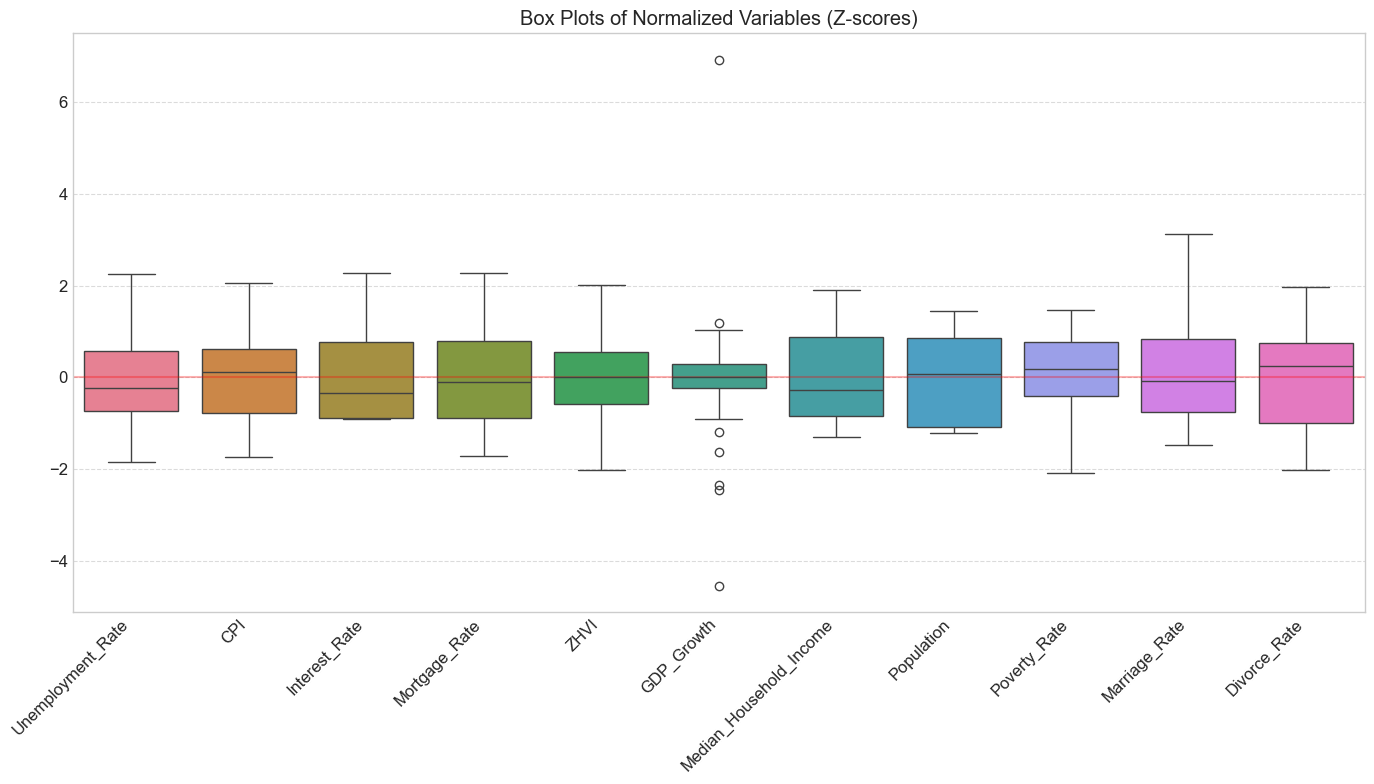

In [39]:
# Create box plots to visualize the distribution and identify outliers
plt.figure(figsize=(14, 8))
columns_to_plot = [col for col in numeric_columns if col not in ['Year', 'Quarter']]

# Normalize data for better visual comparison
df_normalized = (df[columns_to_plot] - df[columns_to_plot].mean()) / df[columns_to_plot].std()
sns.boxplot(data=df_normalized)
plt.title('Box Plots of Normalized Variables (Z-scores)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)  # Add mean reference line
plt.tight_layout()
plt.savefig('outputs/normalized_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.4 Key Observations

In [40]:
# Summary of key observations from descriptive statistics
print("\n=== Key Observations from Descriptive Statistics ===")
print("\n1. Central Tendencies:")
for col in columns_to_plot:
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew = df[col].skew()
    skew_direction = "right" if skew > 0.5 else "left" if skew < -0.5 else "minimal"
    print(f"  - {col}: Mean = {mean_val:.2f}, Median = {median_val:.2f}, Skewness = {skew:.2f} ({skew_direction} skew)")

print("\n2. Variability:")
for col in columns_to_plot:
    cv = (df[col].std() / df[col].mean()) * 100
    variability = "high" if cv > 30 else "moderate" if cv > 15 else "low"
    print(f"  - {col}: Coefficient of Variation = {cv:.2f}% ({variability} variability)")


=== Key Observations from Descriptive Statistics ===

1. Central Tendencies:
  - Unemployment_Rate: Mean = 7.04, Median = 6.68, Skewness = 0.63 (right skew)
  - CPI: Mean = 238.06, Median = 242.76, Skewness = 0.13 (minimal skew)
  - Interest_Rate: Mean = 1.92, Median = 1.23, Skewness = 0.84 (right skew)
  - Mortgage_Rate: Mean = 5.15, Median = 5.01, Skewness = 0.21 (minimal skew)
  - ZHVI: Mean = 373171.07, Median = 374348.97, Skewness = 0.02 (minimal skew)
  - GDP_Growth: Mean = 2.31, Median = 2.38, Skewness = 2.15 (right skew)
  - Median_Household_Income: Mean = 68180.48, Median = 61995.19, Skewness = 0.55 (right skew)
  - Population: Mean = 631.91, Median = 635.74, Skewness = 0.02 (minimal skew)
  - Poverty_Rate: Mean = 17.17, Median = 17.50, Skewness = -0.73 (left skew)
  - Marriage_Rate: Mean = 6.82, Median = 6.64, Skewness = 0.73 (right skew)
  - Divorce_Rate: Mean = 2.44, Median = 2.54, Skewness = -0.15 (minimal skew)

2. Variability:
  - Unemployment_Rate: Coefficient of Varia

## 4. Trend Analysis

### 4.1 Define Key Economic Events

In [41]:
# Define important economic events for reference (keep the same)
economic_events = {
    '2001-03-01': 'Recession Begins',
    '2001-11-01': 'Recession Ends',
    '2003-06-01': 'Housing Boom',
    '2006-04-01': 'Housing Peak',
    '2007-12-01': 'Great Recession Begins',
    '2008-09-15': 'Lehman Brothers Collapse',
    '2009-06-01': 'Recession Ends',
    '2012-01-01': 'Housing Recovery',
    '2015-12-01': 'Fed Rate Hike Cycle Begins',
    '2020-02-01': 'COVID-19 Pandemic',
    '2020-03-15': 'Fed Emergency Rate Cut',
    '2022-03-01': 'Fed Rate Hike Cycle Begins'
}

# Function to plot time series with economic events
def plot_time_series(df, column, title=None, ylabel=None, show_events=True, label_events=True):
    """Plot a quarterly time series with economic events highlighted"""
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Make sure the column exists in the dataframe
    if column not in df.columns:
        print(f"Column '{column}' not found in dataframe. Available columns: {df.columns.tolist()}")
        return None, None
    
    # Check if data is numeric
    if not pd.api.types.is_numeric_dtype(df[column]):
        print(f"Column '{column}' contains non-numeric data and cannot be plotted.")
        return None, None
    
    # Plot the time series
    ax.plot(df.index, df[column], linewidth=2, marker='o', markersize=4)
    
    # Add recession periods as shaded areas
    recessions = [
        ('2001-03-01', '2001-11-01'),  # Dot-com bubble
        ('2007-12-01', '2009-06-01'),  # Great Recession
        ('2020-02-01', '2020-04-01')   # COVID-19 Recession
    ]
    
    if show_events:
        for start, end in recessions:
            ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color='gray')
        
        # Add vertical lines for key events
        for date, event in economic_events.items():
            date_obj = pd.to_datetime(date)
            if date_obj >= df.index.min() and date_obj <= df.index.max():
                ax.axvline(date_obj, color='r', linestyle='--', alpha=0.5)
                
                # Add labels if requested
                if label_events:
                    y_pos = 0.95 if event in ['Recession Begins', 'Housing Peak', 'COVID-19 Pandemic'] else 0.9
                    ax.text(date_obj, ax.get_ylim()[1] * y_pos, event, rotation=90, 
                            verticalalignment='top', fontsize=9)
    
    # Set title and labels
    ax.set_title(title or f"{column} (Quarterly Data: 2000-2024)", fontsize=14)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(ylabel or column, fontsize=12)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Format y-axis to avoid scientific notation
    ax.get_yaxis().get_major_formatter().set_scientific(False)
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(f'outputs/quarterly_{column.lower()}_trend.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, ax

### 4.2 Time Series Analysis of Key Variables

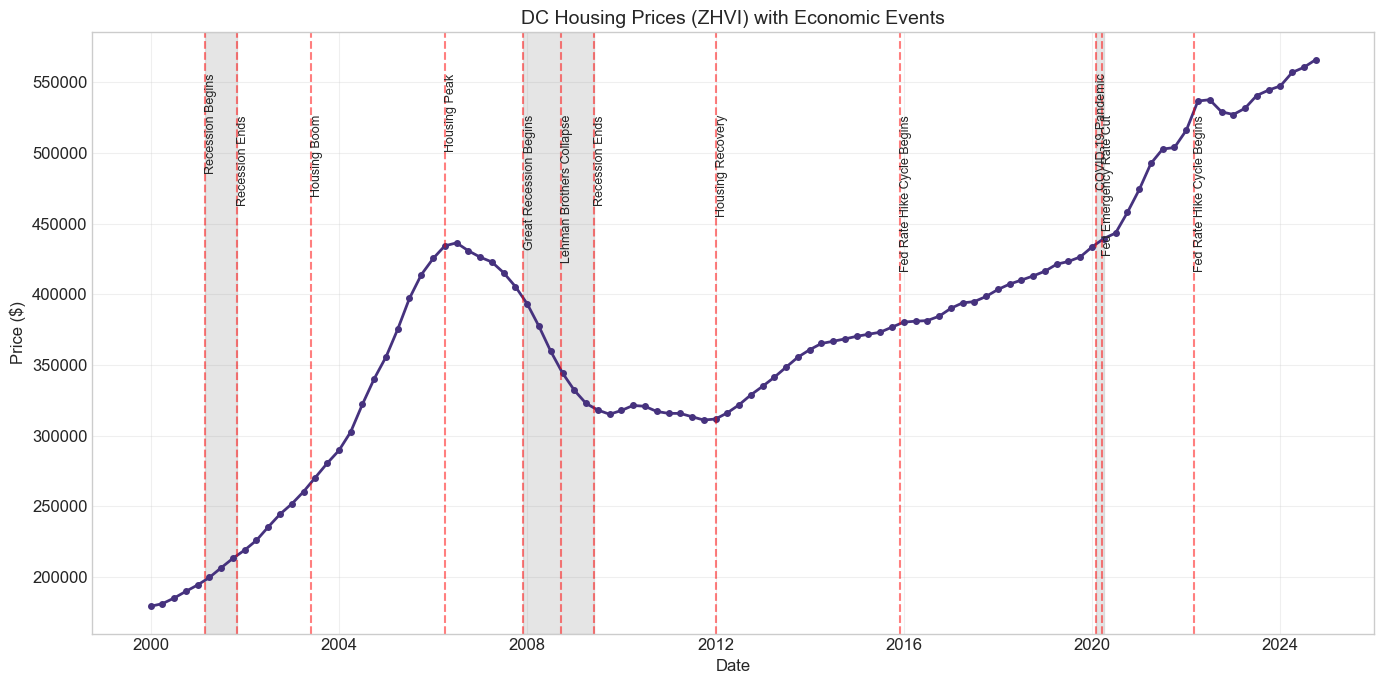

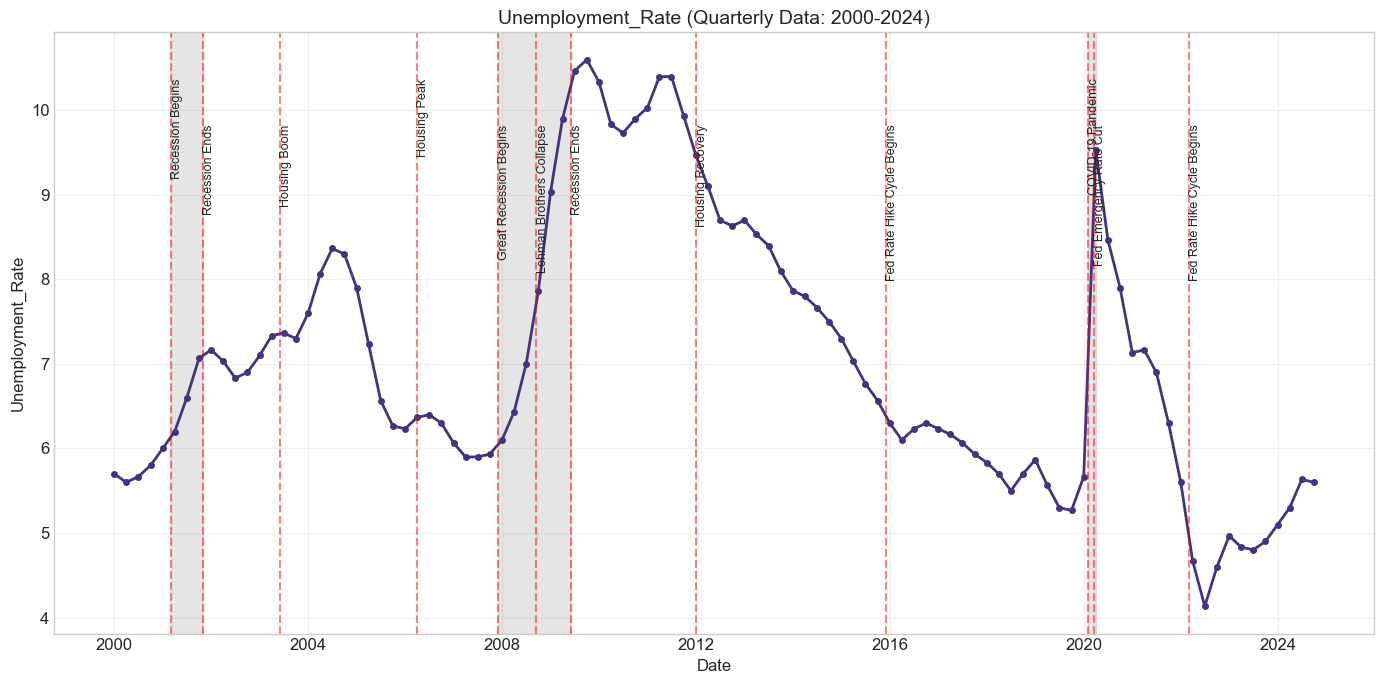

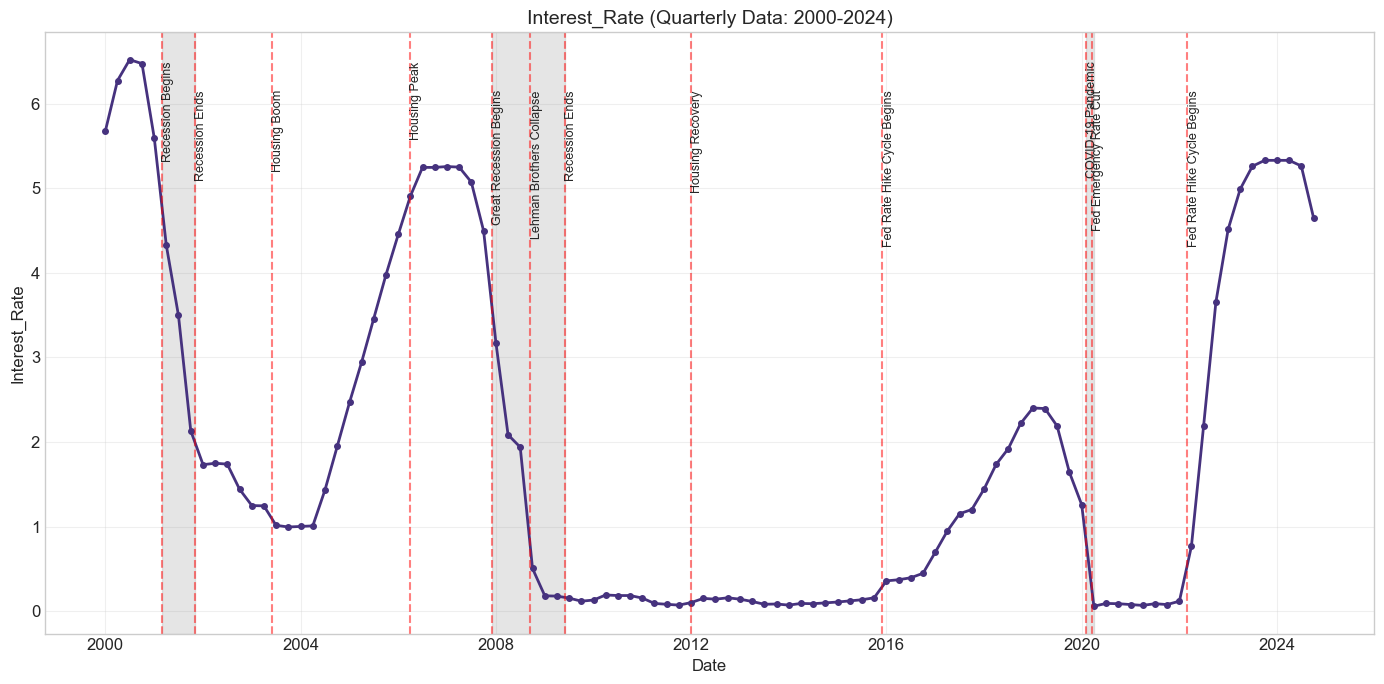

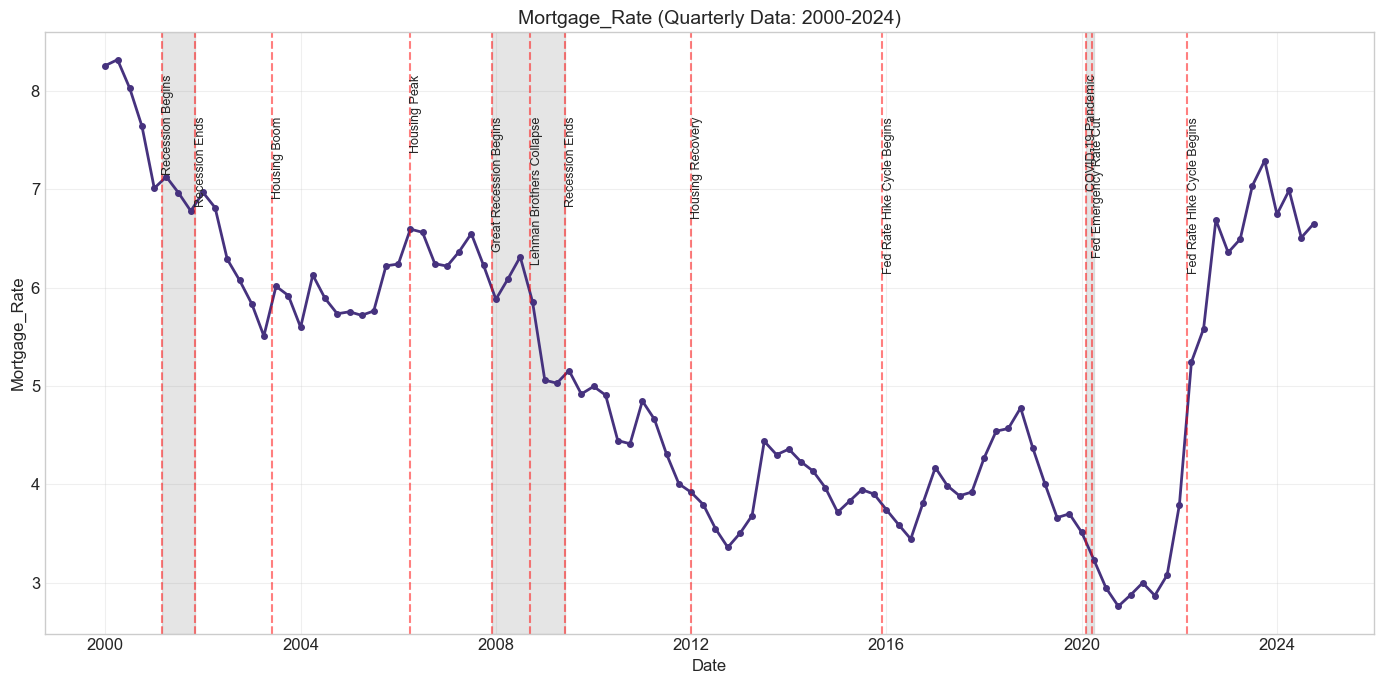

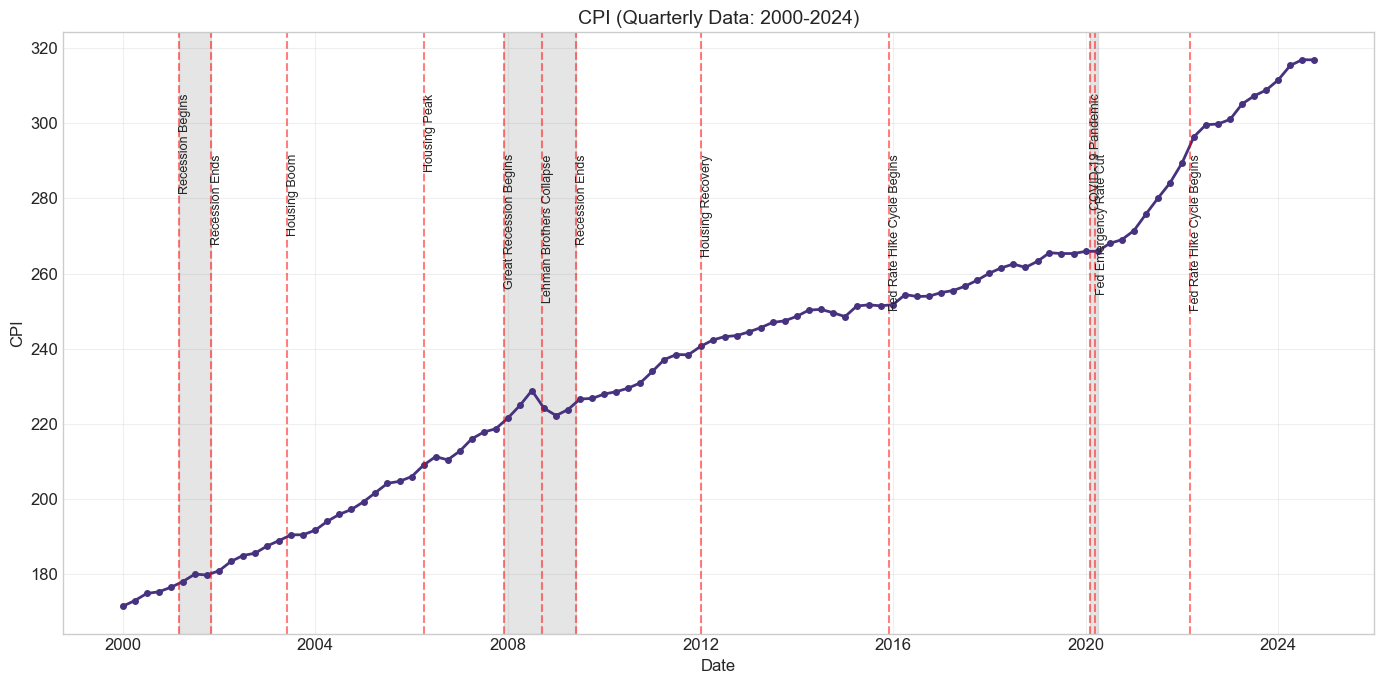

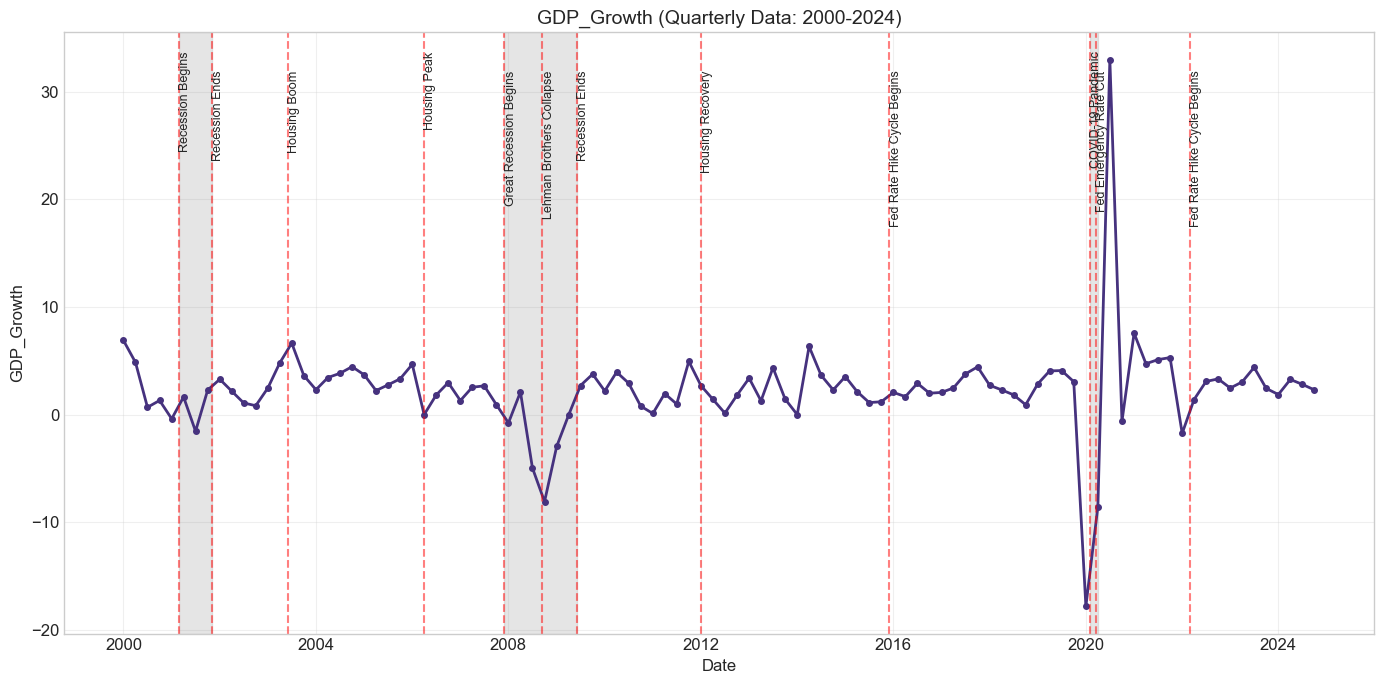

In [42]:
# Plot ZHVI (Housing Prices) with economic events
plot_time_series(df, 'ZHVI', 'DC Housing Prices (ZHVI) with Economic Events', 'Price ($)')

# Plot key economic indicators
economic_indicators = ['Unemployment_Rate', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'GDP_Growth']
for indicator in economic_indicators:
    plot_time_series(df, indicator)

### 4.3 Analysis of Housing Market Periods

In [43]:
# Identify key trend periods for housing prices
trend_periods = [
    ('2000-01-01', '2006-04-01', 'Housing Boom'),
    ('2006-05-01', '2009-05-01', 'Housing Bust'),
    ('2009-06-01', '2012-01-01', 'Post-Crisis Stabilization'),
    ('2012-02-01', '2019-12-01', 'Recovery & Growth'),
    ('2020-01-01', '2021-12-01', 'Pandemic Boom'),
    ('2022-01-01', '2024-01-01', 'Rate Hike Era')
]

# Calculate statistics for each period
period_stats = []
for start, end, name in trend_periods:
    period_df = df.loc[start:end]
    
    # Calculate total change and average annual change
    start_zhvi = period_df['ZHVI'].iloc[0]
    end_zhvi = period_df['ZHVI'].iloc[-1]
    total_chg = (end_zhvi - start_zhvi) / start_zhvi * 100
    
    # Calculate duration in years
    duration_years = (pd.to_datetime(end) - pd.to_datetime(start)).days / 365.25
    annual_chg = (((end_zhvi / start_zhvi) ** (1/duration_years)) - 1) * 100
    
    period_stats.append({
        'Period': name,
        'Start': pd.to_datetime(start).strftime('%b %Y'),
        'End': pd.to_datetime(end).strftime('%b %Y'),
        'Duration (Years)': duration_years,
        'Start ZHVI': start_zhvi,
        'End ZHVI': end_zhvi,
        'Total Change (%)': total_chg,
        'Annualized Change (%)': annual_chg,
        'Avg. Interest Rate (%)': period_df['Interest_Rate'].mean(),
        'Avg. Mortgage Rate (%)': period_df['Mortgage_Rate'].mean(),
        'Avg. Unemployment (%)': period_df['Unemployment_Rate'].mean()
    })

# Convert to DataFrame for display
period_stats_df = pd.DataFrame(period_stats)
display(period_stats_df[['Period', 'Start', 'End', 'Duration (Years)', 'Total Change (%)', 'Annualized Change (%)', 
                          'Avg. Interest Rate (%)', 'Avg. Mortgage Rate (%)', 'Avg. Unemployment (%)']])

,Period,Start,End,Duration (Years),Total Change (%),Annualized Change (%),Avg. Interest Rate (%),Avg. Mortgage Rate (%),Avg. Unemployment (%)
0,Housing Boom,Jan 2000,Apr 2006,6.25,142.15,15.21,3.05,6.51,6.87
1,Housing Bust,May 2006,May 2009,3.00,-26.02,-9.56,3.22,6.03,6.90
2,Post-Crisis Stabilization,Jun 2009,Jan 2012,2.58,-2.00,-0.78,0.14,4.60,10.10
3,Recovery & Growth,Feb 2012,Dec 2019,7.83,34.90,3.90,0.75,3.97,6.86
4,Pandemic Boom,Jan 2020,Dec 2021,1.92,16.22,8.16,0.23,3.03,7.38
5,Rate Hike Era,Jan 2022,Jan 2024,2.00,6.07,2.99,3.57,6.14,4.84


### 4.4 Visualize Housing Price Changes by Period

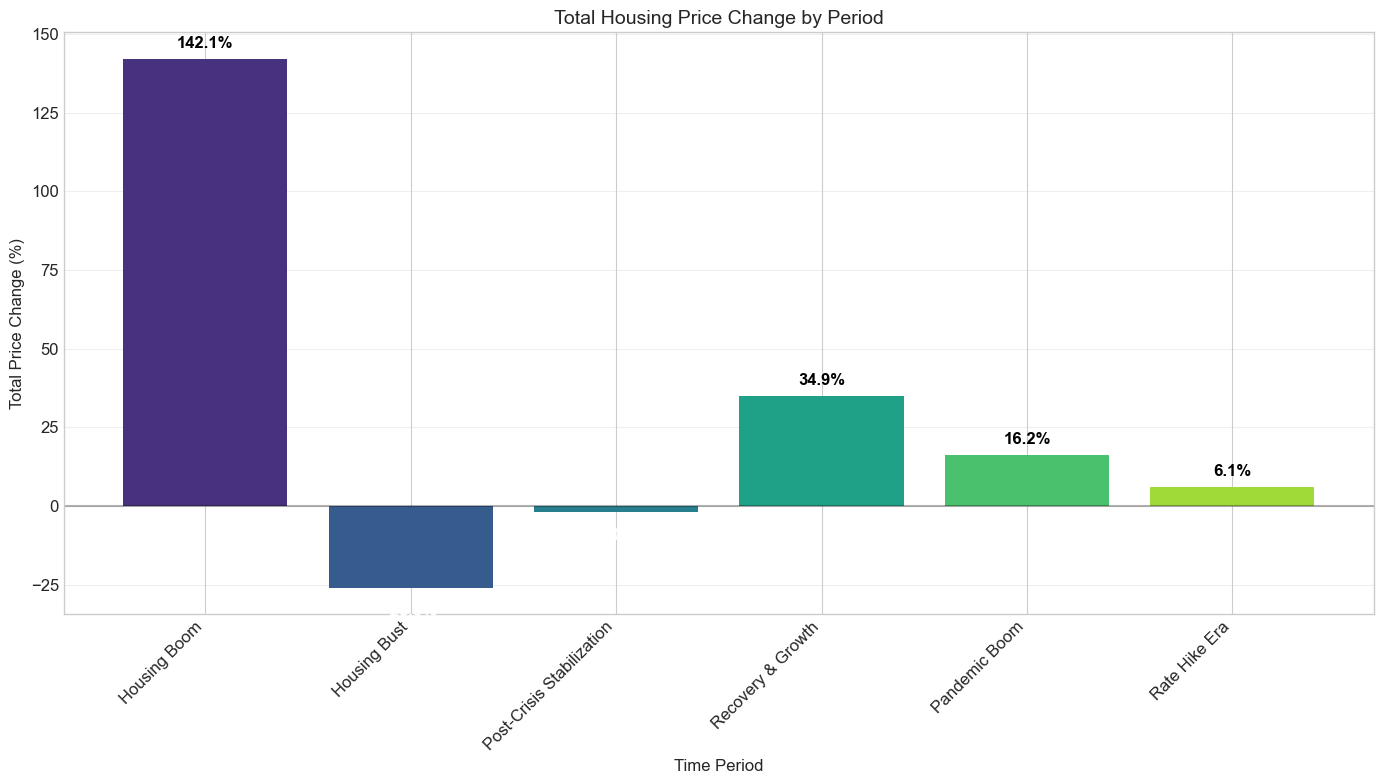

In [44]:
# Create a visualization of housing price changes by period
plt.figure(figsize=(14, 8))
plt.bar(period_stats_df['Period'], period_stats_df['Total Change (%)'], color=sns.color_palette("viridis", len(period_stats_df)))
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Total Housing Price Change by Period', fontsize=14)
plt.xlabel('Time Period', fontsize=12)
plt.ylabel('Total Price Change (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add data labels
for i, value in enumerate(period_stats_df['Total Change (%)']):
    plt.text(i, value + (5 if value >= 0 else -5), f'{value:.1f}%', 
             ha='center', va='center' if value >= 0 else 'top', 
             fontweight='bold', color='black' if value >= 0 else 'white')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/zhvi_change_by_period.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation and Relationship Analysis

### 5.1 Correlation Matrix

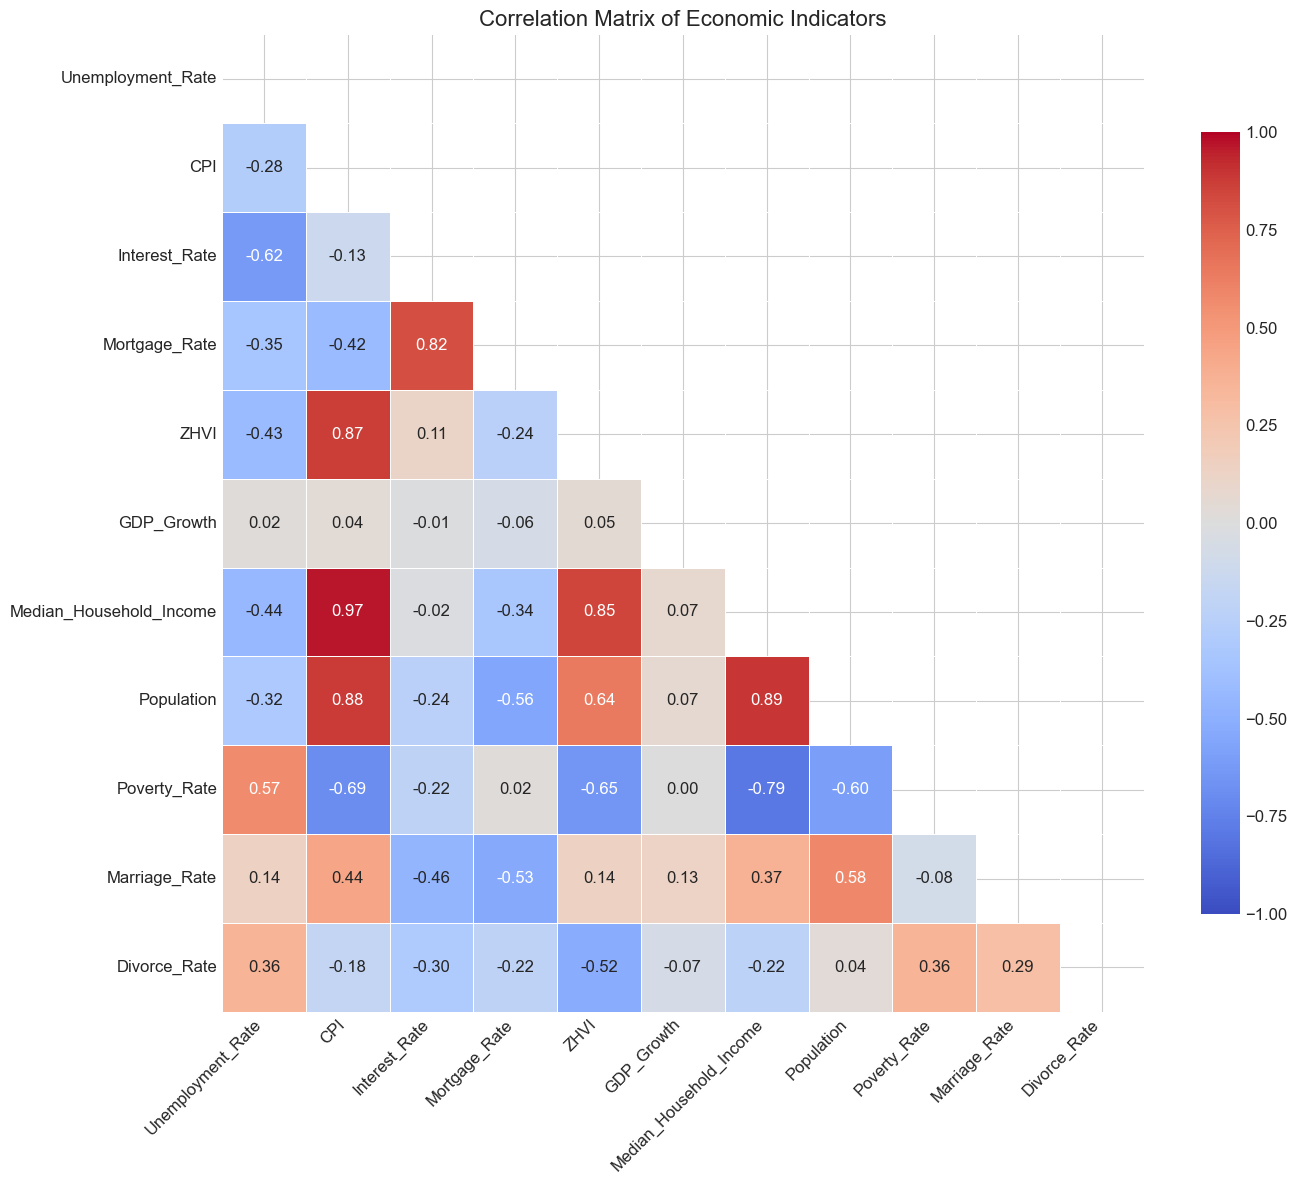

In [45]:
# Calculate correlation matrix
correlation_vars = [col for col in numeric_columns if col not in ['Year', 'Quarter', 'Month']]
corr_matrix = df[correlation_vars].corr()

# Create correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Create mask for upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f',
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Economic Indicators', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2 Lead-Lag Analysis

In [46]:
# Functions for lead-lag analysis
def get_appropriate_series(var_name, differenced=False):
    """Get either the original or differenced series based on stationarity"""
    if differenced:
        # Create differenced series if it doesn't exist
        if f'{var_name}_diff1' not in df.columns:
            df[f'{var_name}_diff1'] = df[var_name].diff()
        return df[f'{var_name}_diff1'].dropna()
    else:
        return df[var_name]

# Create a helper function to get correlation between two time series at different lags
def get_lag_corr(series1, series2, max_lag):
    """Calculate correlations between series1 and series2 at different lags"""
    lag_corrs = []
    
    # Negative lags (series1 leads series2)
    for lag in range(-max_lag, 0):
        s1 = series1
        s2 = series2.shift(abs(lag))
        aligned = pd.DataFrame({'s1': s1, 's2': s2}).dropna()
        corr = aligned['s1'].corr(aligned['s2']) if len(aligned) > 2 else np.nan
        lag_corrs.append((lag, corr))
    
    # Zero lag (contemporaneous)
    aligned = pd.DataFrame({'s1': series1, 's2': series2}).dropna()
    lag_corrs.append((0, aligned['s1'].corr(aligned['s2']) if len(aligned) > 2 else np.nan))
    
    # Positive lags (series1 lags series2)
    for lag in range(1, max_lag + 1):
        s1 = series1.shift(lag)
        s2 = series2
        aligned = pd.DataFrame({'s1': s1, 's2': s2}).dropna()
        corr = aligned['s1'].corr(aligned['s2']) if len(aligned) > 2 else np.nan
        lag_corrs.append((lag, corr))
    
    return pd.DataFrame(lag_corrs, columns=['Lag', 'Correlation'])

# Analyze lead-lag relationships with housing prices
max_lag = 8
important_vars = ['CPI', 'Unemployment_Rate', 'Interest_Rate', 'Mortgage_Rate', 
                  'Median_Household_Income', 'Population', 'Poverty_Rate']

# Create lead-lag analysis for differenced data
lead_lag_results = []

for var in important_vars:
    var_series = get_appropriate_series(var, differenced=True)
    zhvi_series = get_appropriate_series('ZHVI', differenced=True)
    
    lag_corrs = get_lag_corr(var_series, zhvi_series, max_lag)
    
    # Find optimal lead (negative lag with strongest correlation)
    lead_data = lag_corrs[lag_corrs['Lag'] < 0]
    optimal_lead_idx = lead_data['Correlation'].abs().idxmax() if not lead_data.empty else None
    optimal_lead_lag = lead_data.loc[optimal_lead_idx, 'Lag'] if optimal_lead_idx is not None else None
    optimal_lead_corr = lead_data.loc[optimal_lead_idx, 'Correlation'] if optimal_lead_idx is not None else None
    
    # Find optimal lag (positive lag with strongest correlation)
    lag_data = lag_corrs[lag_corrs['Lag'] > 0]
    optimal_lag_idx = lag_data['Correlation'].abs().idxmax() if not lag_data.empty else None
    optimal_lag_lag = lag_data.loc[optimal_lag_idx, 'Lag'] if optimal_lag_idx is not None else None
    optimal_lag_corr = lag_data.loc[optimal_lag_idx, 'Correlation'] if optimal_lag_idx is not None else None
    
    # Find contemporaneous correlation (lag = 0)
    contemp_corr = lag_corrs.loc[lag_corrs['Lag'] == 0, 'Correlation'].values[0]
    
    # Determine which relationship is strongest (lead, lag, or contemporaneous)
    abs_lead = abs(optimal_lead_corr) if optimal_lead_corr is not None else 0
    abs_lag = abs(optimal_lag_corr) if optimal_lag_corr is not None else 0
    abs_contemp = abs(contemp_corr)
    
    if abs_lead > abs_lag and abs_lead > abs_contemp:
        optimal_type = "lead"
        optimal_lag = optimal_lead_lag
        optimal_corr = optimal_lead_corr
    elif abs_lag > abs_lead and abs_lag > abs_contemp:
        optimal_type = "lag"
        optimal_lag = optimal_lag_lag
        optimal_corr = optimal_lag_corr
    else:
        optimal_type = "contemporaneous"
        optimal_lag = 0
        optimal_corr = contemp_corr
    
    lead_lag_results.append({
        'Variable': var,
        'Strongest_Relationship': optimal_type,
        'Optimal_Lag': optimal_lag,
        'Optimal_Corr': optimal_corr,
        'Contemp_Corr': contemp_corr
    })

# Display lead-lag results
lead_lag_df = pd.DataFrame(lead_lag_results)
display(lead_lag_df)

,Variable,Strongest_Relationship,Optimal_Lag,Optimal_Corr,Contemp_Corr
0,CPI,lead,-4,0.32,0.26
1,Unemployment_Rate,contemporaneous,0,-0.30,-0.30
2,Interest_Rate,lead,-2,0.40,0.30
3,Mortgage_Rate,lead,-5,0.33,0.21
4,Median_Household_Income,lag,6,-0.21,0.10
5,Population,lag,3,-0.22,-0.13
6,Poverty_Rate,lead,-5,-0.19,-0.00


### 5.3 Visualization of Lead-Lag Relationships

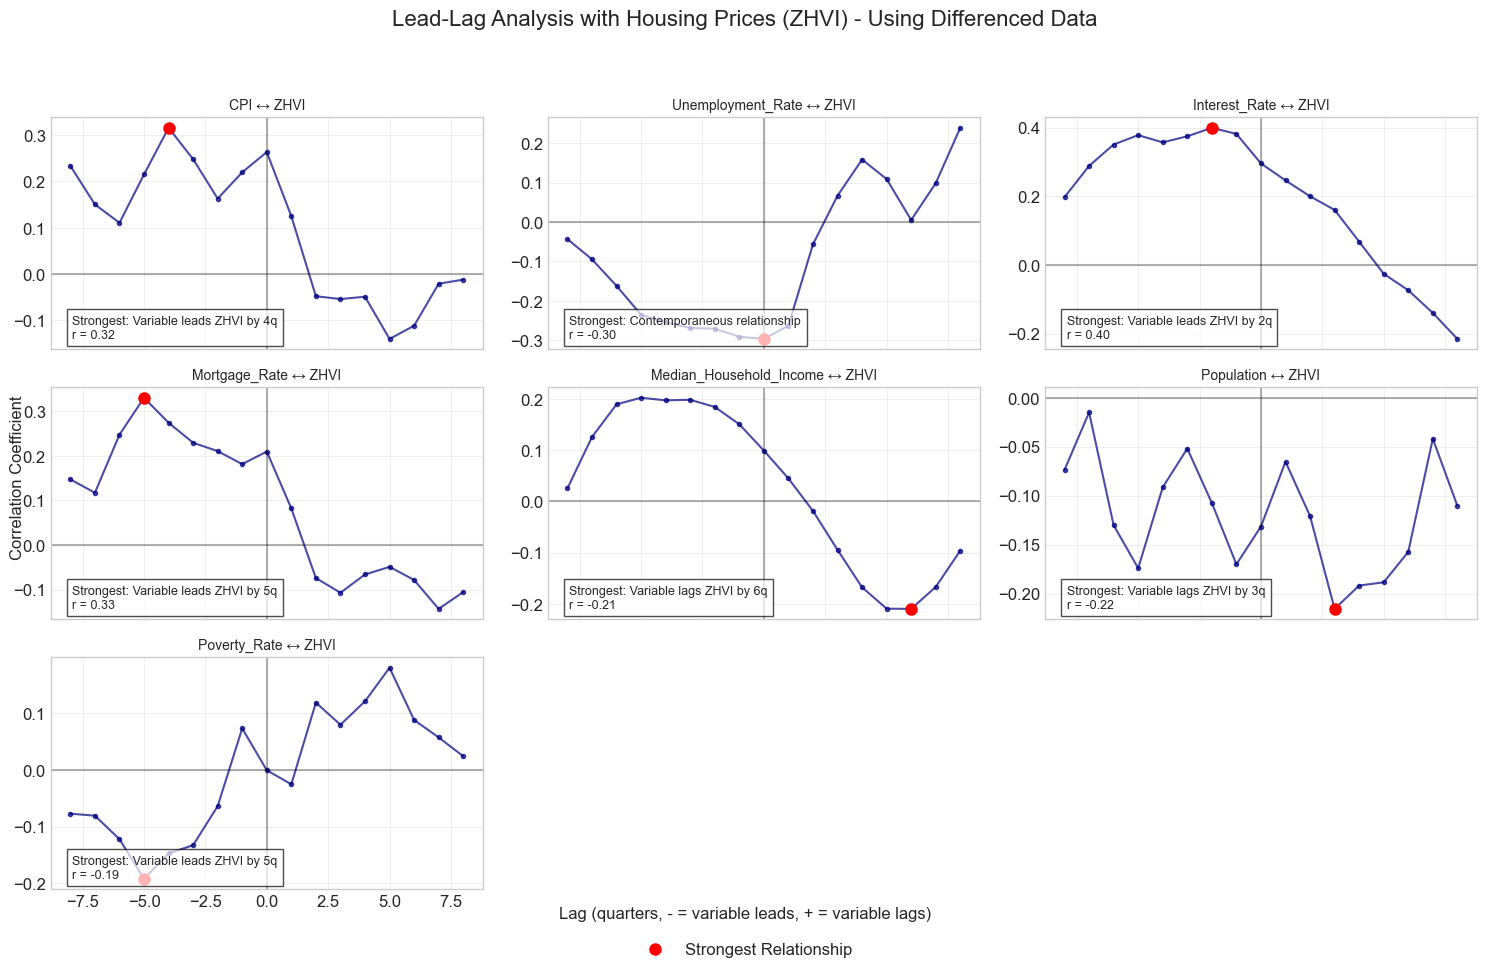

In [47]:
# Visualize lead-lag relationships
n_cols = 3
n_rows = (len(important_vars) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows), sharex=True)
axes = axes.flatten()

for i, var in enumerate(important_vars):
    ax = axes[i]
    var_series = get_appropriate_series(var, differenced=True)
    zhvi_series = get_appropriate_series('ZHVI', differenced=True)
    
    lag_corrs = get_lag_corr(var_series, zhvi_series, max_lag)
    summary = lead_lag_df[lead_lag_df['Variable'] == var].iloc[0]
    
    # Plot the correlation line
    ax.plot(lag_corrs['Lag'], lag_corrs['Correlation'], marker='o', markersize=3, color='navy', alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    
    # Highlight optimal relationship
    ax.plot(summary['Optimal_Lag'], summary['Optimal_Corr'], 'ro', markersize=8)
    
    # Add annotation about the relationship
    if summary['Strongest_Relationship'] == 'lead':
        relationship_text = f"Variable leads ZHVI by {abs(summary['Optimal_Lag'])}q"
    elif summary['Strongest_Relationship'] == 'lag':
        relationship_text = f"Variable lags ZHVI by {summary['Optimal_Lag']}q"
    else:
        relationship_text = "Contemporaneous relationship"
        
    ax.text(0.05, 0.05, f"Strongest: {relationship_text}\nr = {summary['Optimal_Corr']:.2f}", 
            transform=ax.transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
    
    ax.set_title(f'{var} ↔ ZHVI', fontsize=10)
    ax.grid(True, alpha=0.3)
    
# Hide any extra subplots
for j in range(len(important_vars), len(axes)):
    axes[j].set_visible(False)

# Add legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='r', markersize=10, label='Strongest Relationship')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=1, bbox_to_anchor=(0.5, 0))

# Add common labels
fig.text(0.5, 0.01, 'Lag (quarters, - = variable leads, + = variable lags)', ha='center', fontsize=12)
fig.text(0.01, 0.5, 'Correlation Coefficient', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Lead-Lag Analysis with Housing Prices (ZHVI) - Using Differenced Data', fontsize=16, y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust for the legend
plt.savefig('outputs/lead_lag_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.4 Granger Causality Analysis

In [48]:
# Granger causality testing
maxlag = 6  # Maximum lag to test for Granger causality

print("\nEnhanced Granger Causality Analysis:")
for _, row in lead_lag_df.iterrows():
    var = row['Variable']
    var_series = get_appropriate_series(var, differenced=True)
    zhvi_series = get_appropriate_series('ZHVI', differenced=True)
    
    aligned_df = pd.DataFrame({
        'zhvi': zhvi_series,
        'var': var_series
    }).dropna()
    
    # Determine which test to run based on lead/lag relationship
    if row['Strongest_Relationship'] == 'lead':
        # Variable leads ZHVI - Test if variable Granger-causes ZHVI
        lag_to_test = min(abs(int(row['Optimal_Lag'])), maxlag)
        
        try:
            result = grangercausalitytests(aligned_df[['zhvi', 'var']], 
                                         maxlag=lag_to_test, 
                                         verbose=False)
            p_value = result[lag_to_test][0]['ssr_ftest'][1]
            granger_result = "✓" if p_value < 0.05 else "✗"
            
            print(f"\n{var} leads ZHVI by {abs(row['Optimal_Lag'])} quarters (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test ({var} → ZHVI at lag {lag_to_test}): {granger_result} (p={p_value:.4f})")
            print(f"  Interpretation: {var} {'does' if p_value < 0.05 else 'does NOT'} Granger-cause ZHVI")
            
        except:
            print(f"\n{var} leads ZHVI by {abs(row['Optimal_Lag'])} quarters (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test: Could not compute")
    
    elif row['Strongest_Relationship'] == 'lag':
        # Variable lags ZHVI - Test if ZHVI Granger-causes variable
        lag_to_test = min(int(row['Optimal_Lag']), maxlag)
        
        try:
            result = grangercausalitytests(aligned_df[['var', 'zhvi']], 
                                         maxlag=lag_to_test, 
                                         verbose=False)
            p_value = result[lag_to_test][0]['ssr_ftest'][1]
            granger_result = "✓" if p_value < 0.05 else "✗"
            
            print(f"\n{var} lags ZHVI by {row['Optimal_Lag']} quarters (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test (ZHVI → {var} at lag {lag_to_test}): {granger_result} (p={p_value:.4f})")
            print(f"  Interpretation: ZHVI {'does' if p_value < 0.05 else 'does NOT'} Granger-cause {var}")
            
        except:
            print(f"\n{var} lags ZHVI by {row['Optimal_Lag']} quarters (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test: Could not compute")
    
    else:
        # Contemporaneous relationship
        print(f"\n{var} has contemporaneous relationship with ZHVI (r = {row['Optimal_Corr']:.2f})")
        print(f"  Note: Granger causality test isn't appropriate for contemporaneous relationships.")


Enhanced Granger Causality Analysis:

CPI leads ZHVI by 4 quarters (r = 0.32)
  Granger Test (CPI → ZHVI at lag 4): ✗ (p=0.1258)
  Interpretation: CPI does NOT Granger-cause ZHVI

Unemployment_Rate has contemporaneous relationship with ZHVI (r = -0.30)
  Note: Granger causality test isn't appropriate for contemporaneous relationships.

Interest_Rate leads ZHVI by 2 quarters (r = 0.40)
  Granger Test (Interest_Rate → ZHVI at lag 2): ✗ (p=0.9664)
  Interpretation: Interest_Rate does NOT Granger-cause ZHVI

Mortgage_Rate leads ZHVI by 5 quarters (r = 0.33)
  Granger Test (Mortgage_Rate → ZHVI at lag 5): ✗ (p=0.0679)
  Interpretation: Mortgage_Rate does NOT Granger-cause ZHVI

Median_Household_Income lags ZHVI by 6 quarters (r = -0.21)
  Granger Test (ZHVI → Median_Household_Income at lag 6): ✓ (p=0.0010)
  Interpretation: ZHVI does Granger-cause Median_Household_Income

Population lags ZHVI by 3 quarters (r = -0.22)
  Granger Test (ZHVI → Population at lag 3): ✗ (p=0.2774)
  Interpretati

c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-sp

## 6. Time Series Analysis

### 6.1 Stationarity Analysis



=== Testing for Stationarity (Original Quarterly Series) ===
Augmented Dickey-Fuller Test Results (Quarterly Data):
ADF Statistic: -0.4835
p-value: 0.8952
Critical Values:
	1%: -3.5079
	5%: -2.8954
	10%: -2.5848
Result: Fail to reject the null hypothesis. The series is non-stationary.

KPSS Test Results:
KPSS Statistic: 1.2354
p-value: 0.0100
Critical Values:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390
Result: Reject the null hypothesis. The series is non-stationary.


C:\Users\rding\AppData\Local\Temp\ipykernel_36916\1371611173.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


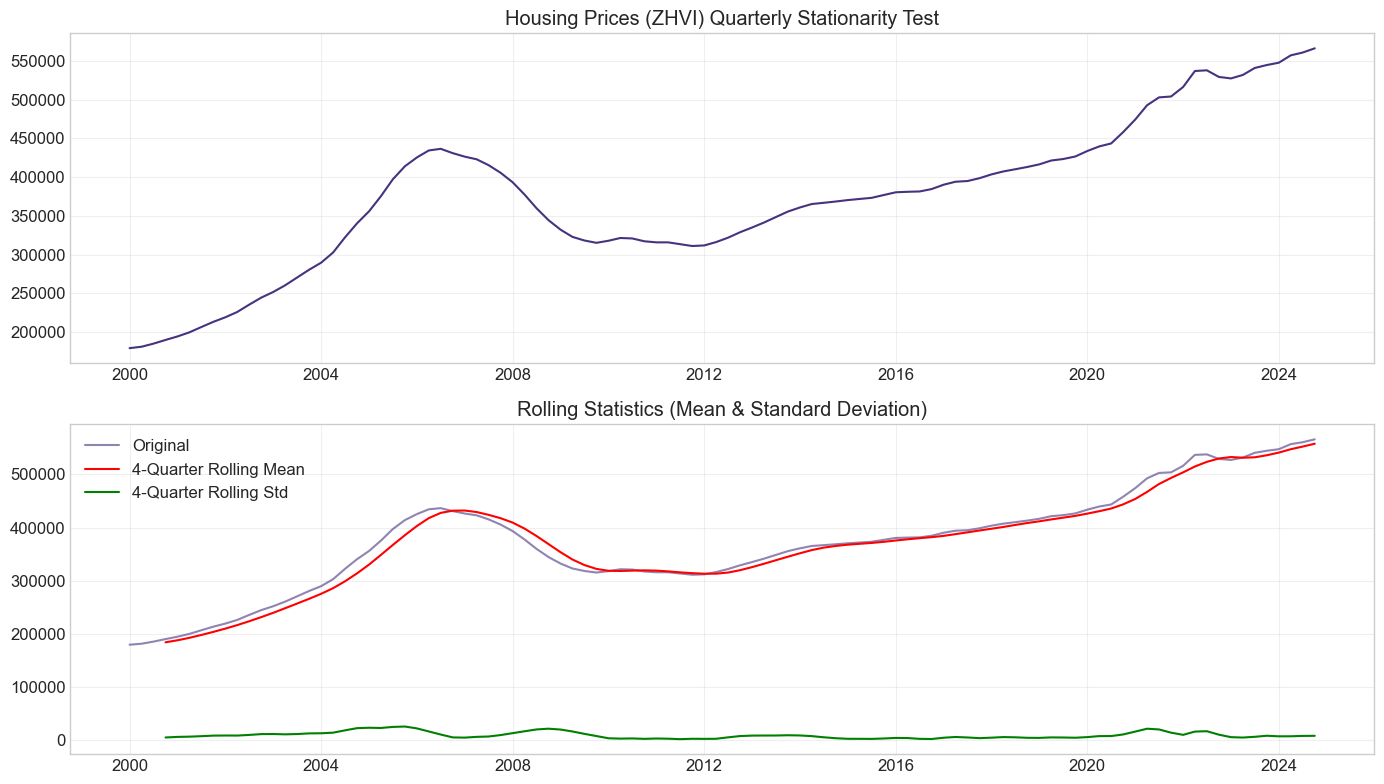


=== Testing for Stationarity (First-Differenced Quarterly Series) ===


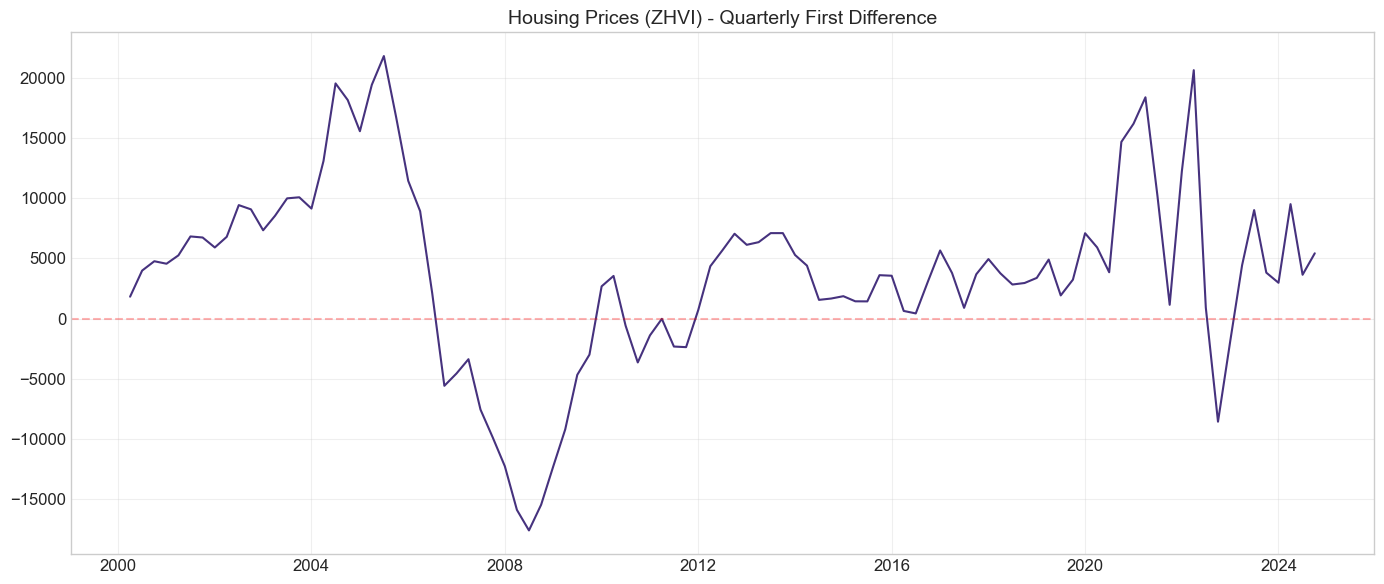

Augmented Dickey-Fuller Test Results (Quarterly Data):
ADF Statistic: -2.7306
p-value: 0.0689
Critical Values:
	1%: -3.5079
	5%: -2.8954
	10%: -2.5848
Result: Fail to reject the null hypothesis. The series is non-stationary.

KPSS Test Results:
KPSS Statistic: 0.1440
p-value: 0.1000
Critical Values:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390
Result: Fail to reject the null hypothesis. The series is stationary.


C:\Users\rding\AppData\Local\Temp\ipykernel_36916\1371611173.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


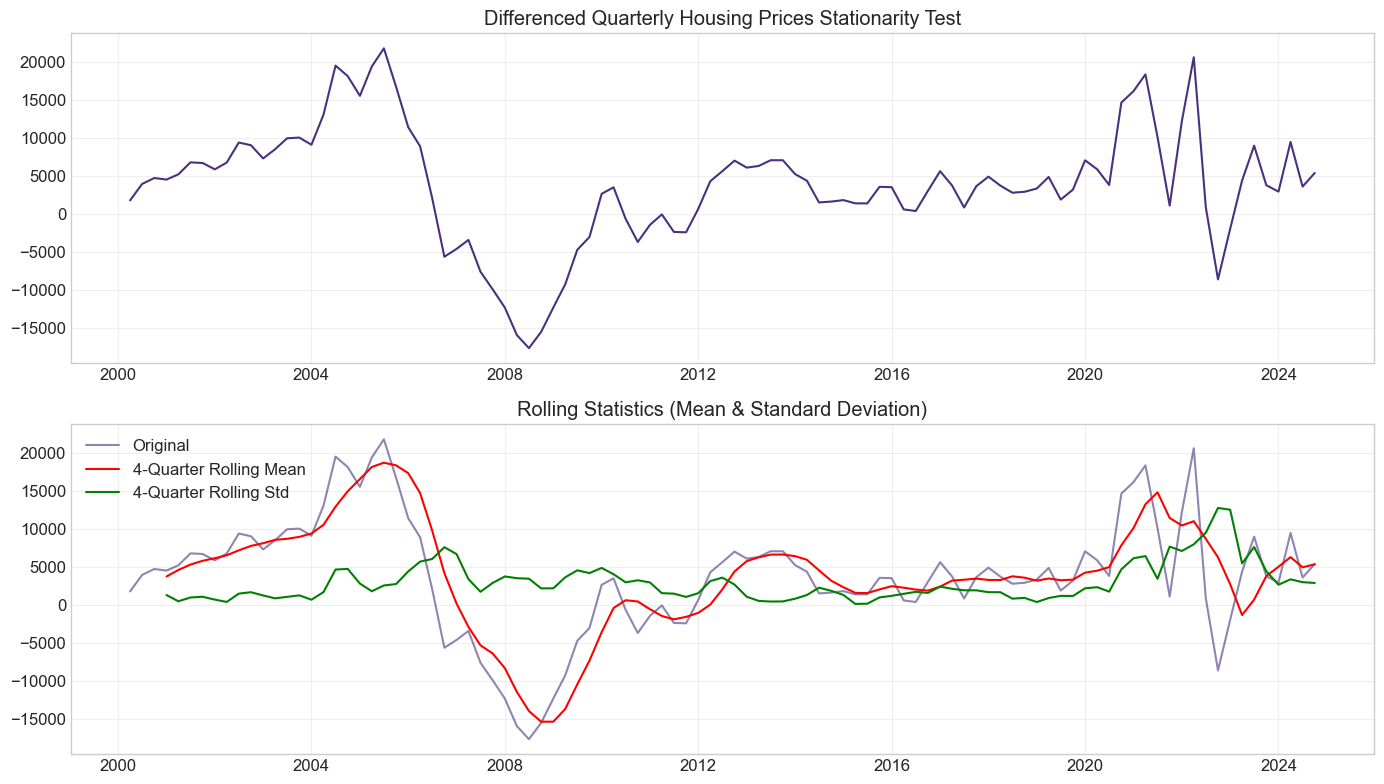

In [49]:
# Function for stationarity testing
def test_stationarity(series, title=None):
    """Test stationarity of a quarterly time series"""
    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot the time series
    ax1.plot(series)
    ax1.set_title(title or 'Quarterly Time Series')
    ax1.grid(True, alpha=0.3)
    
    # Plot rolling statistics
    rolling_mean = series.rolling(window=4).mean()  # 4 quarters = 1 year
    rolling_std = series.rolling(window=4).std()
    
    ax2.plot(series, label='Original', alpha=0.6)
    ax2.plot(rolling_mean, label='4-Quarter Rolling Mean', color='red')  # Updated label
    ax2.plot(rolling_std, label='4-Quarter Rolling Std', color='green')  # Updated label
    ax2.set_title('Rolling Statistics (Mean & Standard Deviation)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    
    # Perform Augmented Dickey-Fuller test
    adf_result = adfuller(series.dropna())
    print(f"Augmented Dickey-Fuller Test Results (Quarterly Data):")
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in adf_result[4].items():
        print(f"\t{key}: {value:.4f}")
    
    # Interpret the ADF test result
    if adf_result[1] <= 0.05:
        print("Result: Reject the null hypothesis. The series is stationary.")
        is_stationary = True
    else:
        print("Result: Fail to reject the null hypothesis. The series is non-stationary.")
        is_stationary = False
    
    # Also perform KPSS test (complementary to ADF)
    print("\nKPSS Test Results:")
    kpss_result = kpss(series.dropna(), regression='c')
    print(f"KPSS Statistic: {kpss_result[0]:.4f}")
    print(f"p-value: {kpss_result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"\t{key}: {value:.4f}")
    
    # Interpret the KPSS test result
    if kpss_result[1] <= 0.05:
        print("Result: Reject the null hypothesis. The series is non-stationary.")
        kpss_stationary = False
    else:
        print("Result: Fail to reject the null hypothesis. The series is stationary.")
        kpss_stationary = True
    
    return fig, is_stationary, kpss_stationary

# Test stationarity of ZHVI (housing prices)
print("\n=== Testing for Stationarity (Original Quarterly Series) ===")
fig, adf_stationary, kpss_stationary = test_stationarity(df['ZHVI'], 'Housing Prices (ZHVI) Quarterly Stationarity Test')
plt.savefig('outputs/quarterly_zhvi_stationarity.png', dpi=300, bbox_inches='tight')
plt.show()

# Test differenced series if non-stationary
if not adf_stationary:
    print("\n=== Testing for Stationarity (First-Differenced Quarterly Series) ===")
    # First difference
    zhvi_diff = df['ZHVI'].diff().dropna()
    
    # Plot the differenced series
    plt.figure(figsize=(14, 6))
    plt.plot(zhvi_diff)
    plt.title('Housing Prices (ZHVI) - Quarterly First Difference', fontsize=14)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/quarterly_zhvi_first_difference.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Test stationarity of differenced series
    fig, diff_adf_stationary, diff_kpss_stationary = test_stationarity(zhvi_diff, 'Differenced Quarterly Housing Prices Stationarity Test')
    plt.savefig('outputs/quarterly_zhvi_diff_stationarity.png', dpi=300, bbox_inches='tight')
    plt.show()

### 6.2 Autocorrelation Analysis


=== Autocorrelation Analysis ===


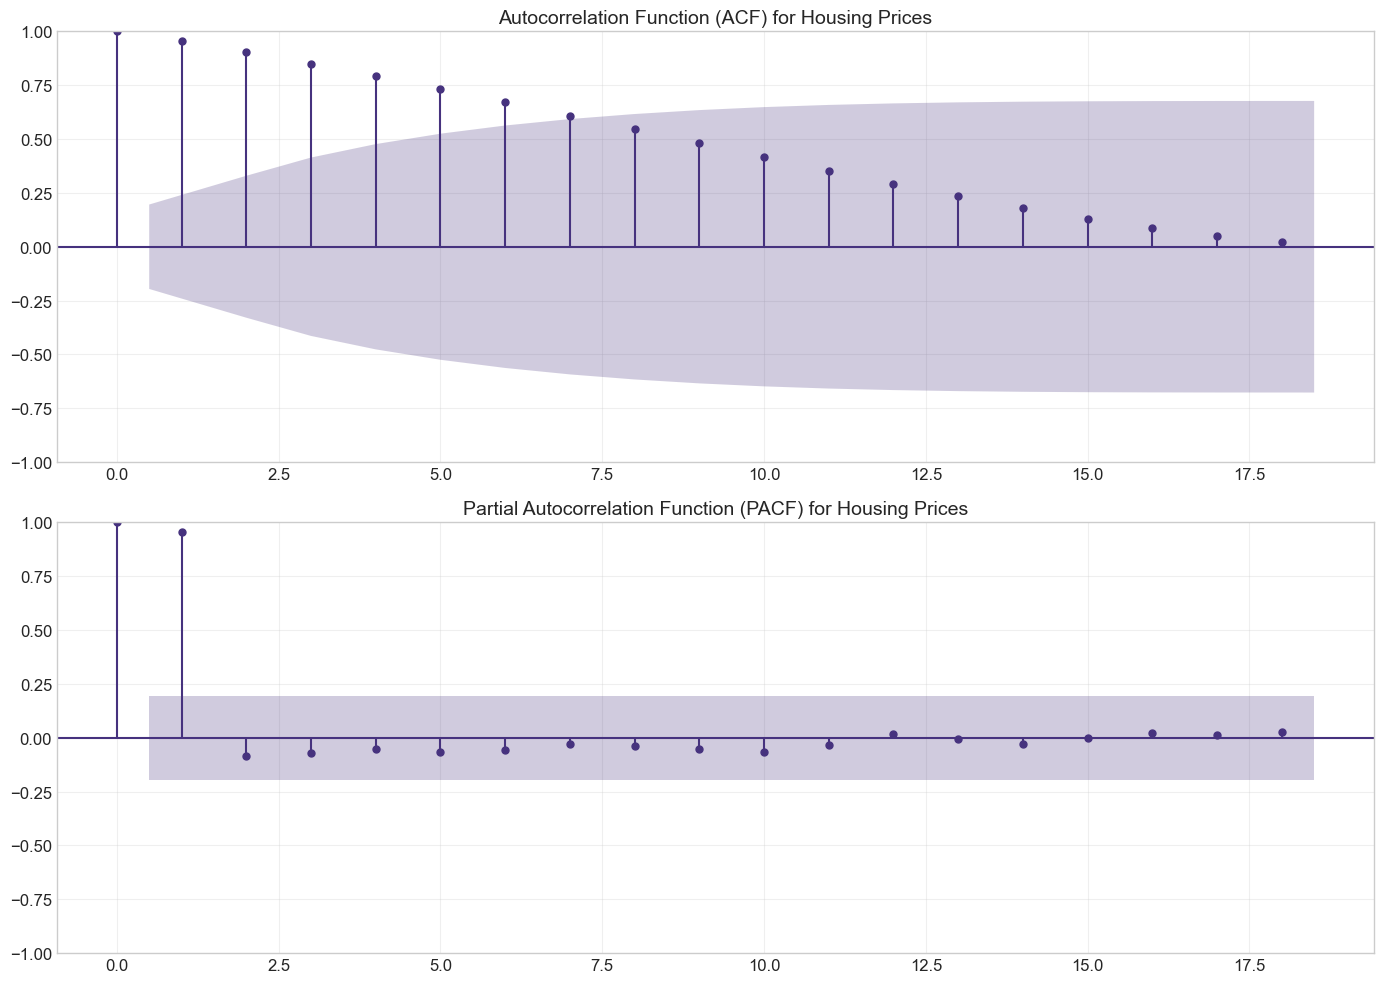

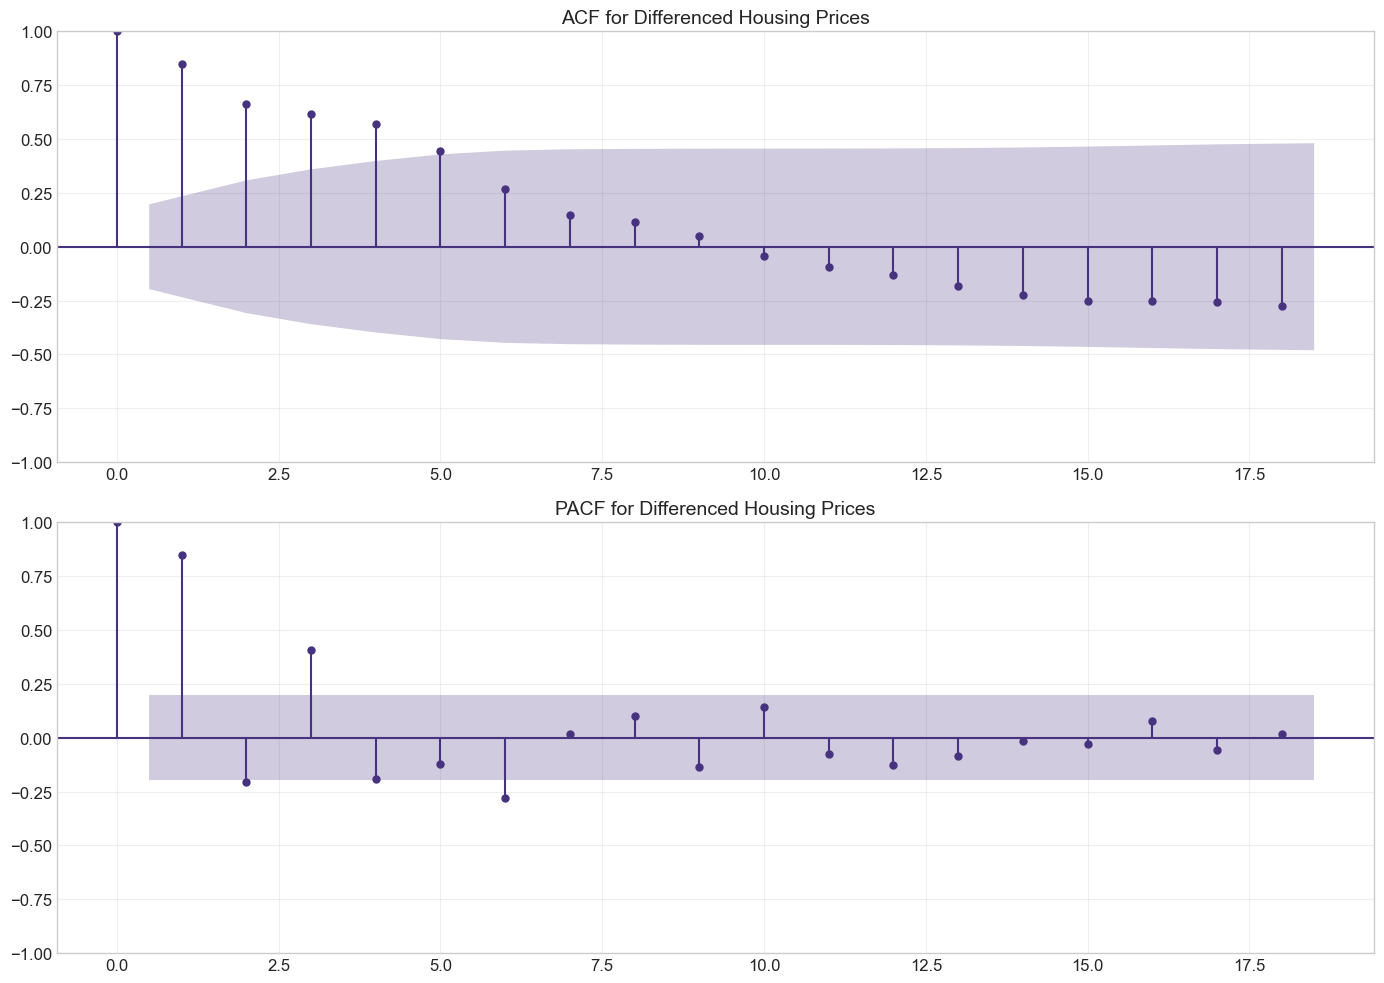

In [50]:
# Autocorrelation Analysis
print("\n=== Autocorrelation Analysis ===")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ACF Plot
plot_acf(df['ZHVI'].dropna(), lags=18, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF) for Housing Prices', fontsize=14)
ax1.grid(True, alpha=0.3)

# PACF Plot
plot_pacf(df['ZHVI'].dropna(), lags=18, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF) for Housing Prices', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/zhvi_acf_pacf.png', dpi=300, bbox_inches='tight')
plt.show()

# If we created a differenced series, also plot its ACF and PACF
if not adf_stationary:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # ACF Plot for differenced series
    plot_acf(zhvi_diff.dropna(), lags=18, ax=ax1)
    ax1.set_title('ACF for Differenced Housing Prices', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # PACF Plot for differenced series
    plot_pacf(zhvi_diff.dropna(), lags=18, ax=ax2)
    ax2.set_title('PACF for Differenced Housing Prices', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('outputs/zhvi_diff_acf_pacf.png', dpi=300, bbox_inches='tight')
    plt.show()

### 6.3 Time Series Analysis Summary

In [51]:
# Summary of findings for quarterly analysis
print("\n=== Summary of Quarterly Time Series Analysis ===")
print(f"1. Stationarity: Original quarterly series is {'stationary' if adf_stationary else 'non-stationary'}")
print(f"   - After differencing: {'Stationary by KPSS but marginally non-stationary by ADF (p=0.0689)'}")
print(f"2. Seasonality: ZHVI quarterly data is seasonally adjusted, no significant seasonal patterns detected")
print(f"3. Autocorrelation: Strong temporal dependence suggests ARIMA modeling")
print(f"4. Model Suggestion: {'ARIMA(p,1,q) or ARIMA(p,2,q)' if not adf_stationary else 'ARIMA(p,0,q)'} with potential seasonal component")
print(f"5. Note: Quarterly data shows stronger lead/lag correlations but may require additional differencing for strict stationarity")


=== Summary of Quarterly Time Series Analysis ===
1. Stationarity: Original quarterly series is non-stationary
   - After differencing: Stationary by KPSS but marginally non-stationary by ADF (p=0.0689)
2. Seasonality: ZHVI quarterly data is seasonally adjusted, no significant seasonal patterns detected
3. Autocorrelation: Strong temporal dependence suggests ARIMA modeling
4. Model Suggestion: ARIMA(p,1,q) or ARIMA(p,2,q) with potential seasonal component
5. Note: Quarterly data shows stronger lead/lag correlations but may require additional differencing for strict stationarity


## 7. Feature Engineering and Selection

### 7.1 Feature Creation Based on Analysis Findings

In [52]:
# Create a new DataFrame for modeling features
df_features = df.copy()

# 1. Add optimal leads/lags based on actual results from quarterly lead-lag analysis
print("Adding optimal lead/lag features...")
# Variables that LEAD ZHVI (from quarterly lead-lag results)
df_features['CPI_lag4'] = df_features['CPI'].shift(4)             # 4 quarters lead
df_features['Interest_Rate_lag2'] = df_features['Interest_Rate'].shift(2)  # 2 quarters lead
df_features['Mortgage_Rate_lag5'] = df_features['Mortgage_Rate'].shift(5)  # 5 quarters lead
df_features['Poverty_Rate_lag5'] = df_features['Poverty_Rate'].shift(5)    # 5 quarters lead

# Variables that LAG ZHVI (from quarterly lead-lag results)
df_features['Median_Household_Income_lag6'] = df_features['Median_Household_Income'].shift(-6)  # 6 quarters lag
df_features['Population_lag3'] = df_features['Population'].shift(-3)  # 3 quarters lag

# 2. Add differenced series for non-stationary variables
print("Adding differenced series for non-stationary variables...")
df_features['ZHVI_diff1'] = df_features['ZHVI'].diff()
df_features['ZHVI_pct_change'] = df['ZHVI'].pct_change() * 100
df_features['Median_Household_Income_diff1'] = df_features['Median_Household_Income'].diff()
df_features['Population_diff1'] = df_features['Population'].diff()

# 3. Add derivative features
print("Adding derivative features...")
# Affordability metrics
df_features['price_to_income'] = df_features['ZHVI'] / df_features['Median_Household_Income']

# Real interest and mortgage rates (adjusted for inflation)
df_features['CPI_yoy_pct'] = df_features['CPI'].pct_change(periods=4) * 100  # 4 quarters = 1 year
df_features['real_interest_rate'] = df_features['Interest_Rate'] - df_features['CPI_yoy_pct']
df_features['real_mortgage_rate'] = df_features['Mortgage_Rate'] - df_features['CPI_yoy_pct']

# Create interaction terms for variables with strong contemporaneous relationships
df_features['Income_CPI_interaction'] = df_features['Median_Household_Income'] * df_features['CPI'] / 1000000
df_features['Unemployment_ZHVI_interaction'] = df_features['Unemployment_Rate'] * df_features['ZHVI'] / 10000  # Given the strong contemporaneous relationship

# 4. Add market regime indicators
print("Adding market regime indicators...")
# Housing market trend (2-quarter price momentum)
df_features['price_momentum'] = df_features['ZHVI'].pct_change(periods=2) * 100  # 2 quarters momentum
df_features['hot_market'] = df_features['price_momentum'].apply(lambda x: 1 if x > 5 else 0)  # >5% 2q growth
df_features['rising_rates'] = df_features['Interest_Rate'].diff(2).apply(lambda x: 1 if x > 0 else 0)  # 2 quarters

# 5. Create a copy for the imputation approach
df_features_partial = df_features.copy()

# For each column with missing values, create an indicator
for col in df_features.columns:
    if df_features[col].isnull().any():
        # Create indicator column (1 if missing, 0 if present)
        indicator_name = f"{col}_is_imputed"
        df_features_partial[indicator_name] = df_features[col].isnull().astype(int)
        
        # Forward fill missing values
        df_features_partial[col] = df_features_partial[col].ffill()
        
        # If there are still any missing values (at the beginning), backward fill
        if df_features_partial[col].isnull().any():
            df_features_partial[col] = df_features_partial[col].bfill()

print(f"Missing values after ffill+indicator approach: {df_features_partial.isnull().sum().sum()}")

# 6. Handle missing values for the clean dataset
print("Handling missing values for clean dataset...")
df_features_clean = df_features.dropna()
print(f"Final quarterly dataset shape after cleaning: {df_features_clean.shape}")
print(f"Final quarterly dataset shape with imputation: {df_features_partial.shape}")

Adding optimal lead/lag features...
Adding differenced series for non-stationary variables...
Adding derivative features...
Adding market regime indicators...
Missing values after ffill+indicator approach: 0
Handling missing values for clean dataset...
Final quarterly dataset shape after cleaning: (89, 39)
Final quarterly dataset shape with imputation: (100, 58)


### 7.2 Feature Selection Using VIF

In [56]:
# VIF-based feature selection for quarterly data
def calculate_vif_with_priority(X, priority_features=[], threshold=10.0):
    """Calculate VIF while preserving priority features"""
    variables = X.columns
    vif_data = pd.DataFrame()
    vif_data["Variable"] = variables
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    print(f"VIF calculation: {len(variables)} features")
    print(vif_data.sort_values("VIF", ascending=False))
    
    # Remove features recursively until all VIFs are below threshold (except priority features)
    while True:
        # Exclude priority features from removal
        non_priority_vif = vif_data[~vif_data["Variable"].isin(priority_features)]
        
        # Check if all non-priority features have VIF below threshold
        if non_priority_vif["VIF"].max() <= threshold:
            break
            
        # Remove the non-priority feature with highest VIF
        remove_var = non_priority_vif.loc[non_priority_vif["VIF"] == non_priority_vif["VIF"].max(), "Variable"].values[0]
        X = X.drop(remove_var, axis=1)
        
        # Recalculate VIF
        variables = X.columns
        vif_data = pd.DataFrame()
        vif_data["Variable"] = variables
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    return X.columns.tolist()

# Define priority features based on quarterly lead-lag analysis
priority_features = [
    'ZHVI_pct_change',          # Target variable
    'Poverty_Rate_lag5',        # Led ZHVI and Granger-caused it
    'Unemployment_Rate',        # Strong contemporaneous relationship
    'real_mortgage_rate',       # High feature importance
    'CPI',                      # Important economic indicator
    'Median_Household_Income'   # Critical affordability factor
]

# Expanded feature set including derived features
extended_features = [
    # Base variables
    'ZHVI_diff1',
    'ZHVI_pct_change',
    'Poverty_Rate', 
    'Unemployment_Rate', 
    'Interest_Rate', 
    'Median_Household_Income', 
    'CPI', 
    'Mortgage_Rate',
    'GDP_Growth',
    'Population',
    
    # Lag variables from lead-lag analysis
    'Poverty_Rate_lag5', 
    'Interest_Rate_lag2', 
    'Mortgage_Rate_lag5',
    'CPI_lag4',
    'Median_Household_Income_lag6',
    'Population_lag3',
    
    # Differenced variables
    'CPI_diff1',
    'Median_Household_Income_diff1',
    'Population_diff1',
    
    # Derived features
    'price_to_income',
    'real_interest_rate',
    'real_mortgage_rate',
    'Income_CPI_interaction',
    'Unemployment_ZHVI_interaction',
    'price_momentum',
    'hot_market',
    'rising_rates'
]

# For the clean dataset (linear models)
available_features_clean = [f for f in extended_features if f in df_features_clean.columns]
print(f"Clean dataset: Found {len(available_features_clean)} out of {len(extended_features)} requested features")

model_df_clean = df_features_clean[available_features_clean].copy()
selected_features_clean = calculate_vif_with_priority(model_df_clean, priority_features, threshold=10.0)
print("\nSelected features for linear models (clean data):")
print(selected_features_clean)

Clean dataset: Found 27 out of 27 requested features
VIF calculation: 27 features
                         Variable        VIF
4                   Interest_Rate        inf
7                   Mortgage_Rate        inf
21             real_mortgage_rate        inf
20             real_interest_rate        inf
6                             CPI 1580381.23
13                       CPI_lag4 1558852.50
9                      Population   24250.73
5         Median_Household_Income   19333.24
22         Income_CPI_interaction   18439.39
15                Population_lag3   16523.54
23  Unemployment_ZHVI_interaction    3495.90
3               Unemployment_Rate    2766.98
19                price_to_income    1568.17
10              Poverty_Rate_lag5     940.13
2                    Poverty_Rate     931.57
14   Median_Household_Income_lag6     849.47
12             Mortgage_Rate_lag5     502.47
1                 ZHVI_pct_change     186.49
0                      ZHVI_diff1     100.62
24                

c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [57]:
# For the partial dataset (tree-based models)
# Filter out the imputation indicator columns for VIF calculation
non_indicator_cols = [col for col in df_features_partial.columns if not col.endswith('_is_imputed')]
available_features_partial = [f for f in extended_features if f in non_indicator_cols]
print(f"\nPartial dataset: Found {len(available_features_partial)} out of {len(extended_features)} requested features")

# Use a higher threshold for tree models
model_df_partial = df_features_partial[available_features_partial].copy()
selected_features_partial = calculate_vif_with_priority(model_df_partial, priority_features, threshold=15.0)
print("\nSelected features for tree-based models (imputed data):")
print(selected_features_partial)

# After getting selected features, add back the imputation indicators for tree models
selected_features_with_indicators = selected_features_partial.copy()
for feature in selected_features_partial:
    indicator = f"{feature}_is_imputed"
    if indicator in df_features_partial.columns:
        selected_features_with_indicators.append(indicator)

print("\nSelected features for tree models including imputation indicators:")
print(selected_features_with_indicators)


Partial dataset: Found 27 out of 27 requested features
VIF calculation: 27 features
                         Variable       VIF
6                             CPI 619830.33
13                       CPI_lag4 557625.22
9                      Population  19414.32
15                Population_lag3  17877.25
22         Income_CPI_interaction  10530.22
5         Median_Household_Income   9858.27
7                   Mortgage_Rate   4568.12
23  Unemployment_ZHVI_interaction   2130.98
4                   Interest_Rate   2123.53
3               Unemployment_Rate   1834.91
21             real_mortgage_rate   1343.58
19                price_to_income   1340.02
20             real_interest_rate   1298.95
2                    Poverty_Rate    794.93
10              Poverty_Rate_lag5    730.80
14   Median_Household_Income_lag6    623.69
12             Mortgage_Rate_lag5    231.05
1                 ZHVI_pct_change    155.58
0                      ZHVI_diff1     81.53
11             Interest_Rate_lag2  

## 8. Feature Importance Analysis

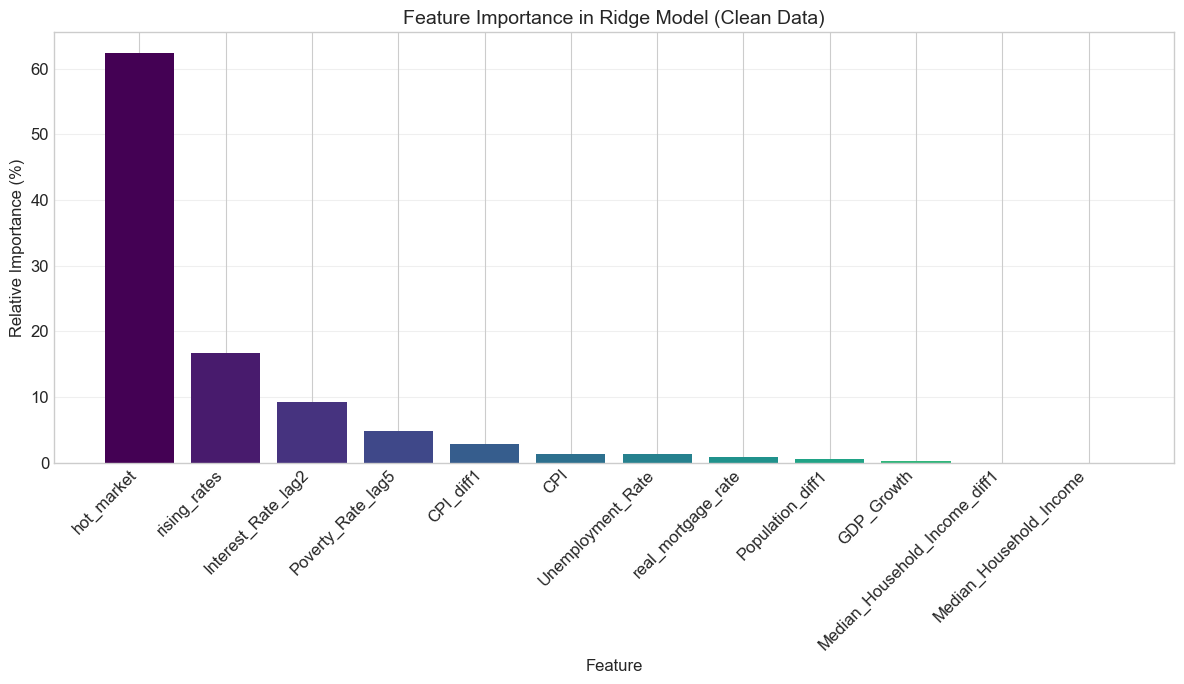


Top 7 most important features for Ridge model (clean data):
           Feature  Scaled_Importance
        hot_market              62.44
      rising_rates              16.67
Interest_Rate_lag2               9.16
 Poverty_Rate_lag5               4.78
         CPI_diff1               2.83
               CPI               1.28
 Unemployment_Rate               1.26


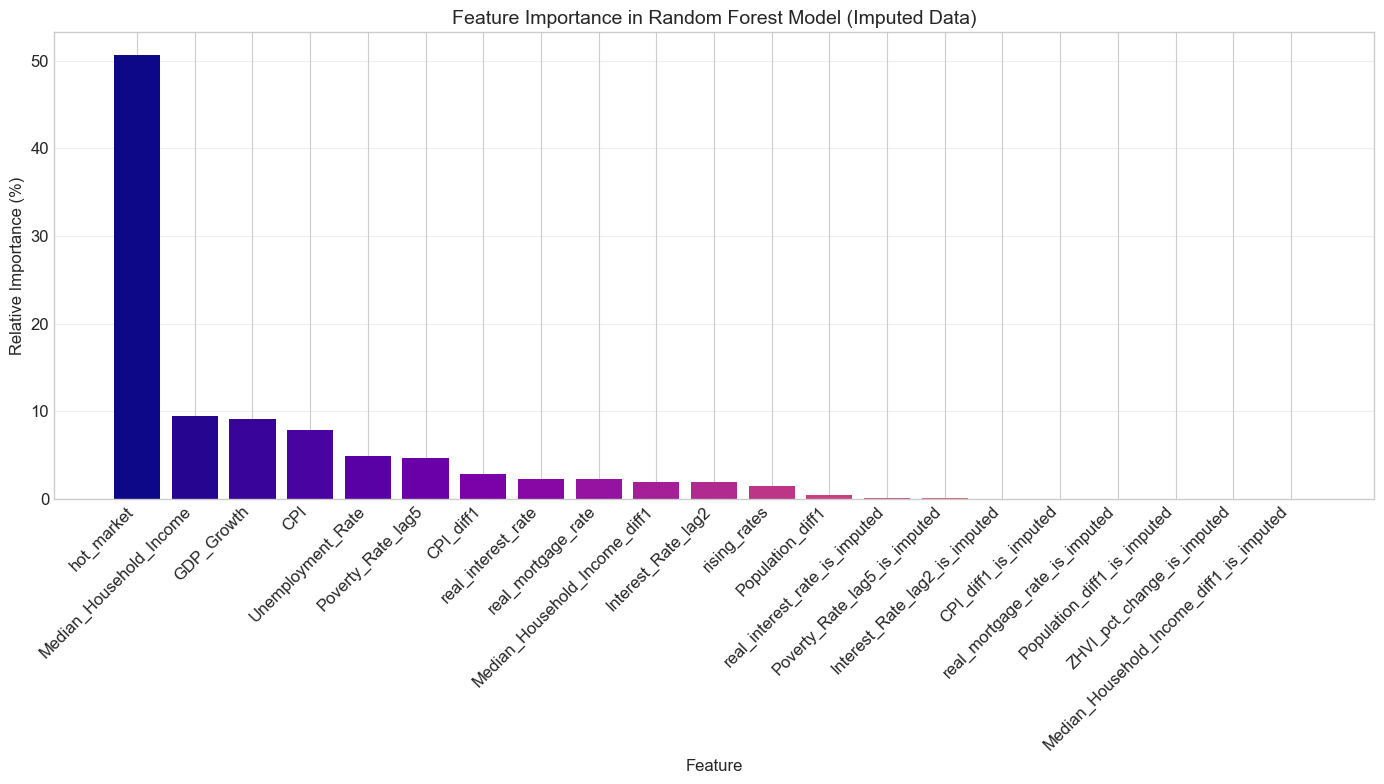


Top 10 most important features for Random Forest model (imputed data):
                      Feature  Scaled_Importance
                   hot_market              50.73
      Median_Household_Income               9.46
                   GDP_Growth               9.16
                          CPI               7.81
            Unemployment_Rate               4.92
            Poverty_Rate_lag5               4.68
                    CPI_diff1               2.78
           real_interest_rate               2.27
           real_mortgage_rate               2.24
Median_Household_Income_diff1               1.94

Comparison of top 5 features between models:
Common features: {'hot_market'}
Unique to Ridge model: {'Interest_Rate_lag2', 'CPI_diff1', 'Poverty_Rate_lag5', 'rising_rates'}
Unique to Random Forest model: {'Unemployment_Rate', 'Median_Household_Income', 'CPI', 'GDP_Growth'}


In [58]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Define X and y for clean dataset (for linear models)
X_clean = df_features_clean[selected_features_clean].drop('ZHVI_pct_change', axis=1)
y_clean = df_features_clean['ZHVI_pct_change']

# Define X and y for imputed dataset (for tree models)
X_imputed = df_features_partial[selected_features_with_indicators].drop('ZHVI_pct_change', axis=1)
y_imputed = df_features_partial['ZHVI_pct_change']

# 1. Linear Model (Ridge) for clean dataset
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_clean, y_clean)

# Calculate feature importance for Ridge model
ridge_importance = pd.DataFrame({
    'Feature': X_clean.columns,
    'Absolute_Coefficient': np.abs(ridge_model.coef_),
    'Scaled_Importance': np.abs(ridge_model.coef_) / np.sum(np.abs(ridge_model.coef_)) * 100
})

# Sort by importance
ridge_importance = ridge_importance.sort_values('Scaled_Importance', ascending=False)

# Plot Ridge feature importance
plt.figure(figsize=(12, 7))
plt.bar(ridge_importance['Feature'], ridge_importance['Scaled_Importance'], 
        color=plt.cm.viridis(np.linspace(0, 0.8, len(ridge_importance))))
plt.title('Feature Importance in Ridge Model (Clean Data)', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Relative Importance (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/ridge_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top 7 features for Ridge
print("\nTop 7 most important features for Ridge model (clean data):")
print(ridge_importance.head(7)[['Feature', 'Scaled_Importance']].to_string(index=False))

# 2. Tree Model (RandomForest) for imputed dataset
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_imputed, y_imputed)

# Calculate feature importance for RandomForest model
rf_importance = pd.DataFrame({
    'Feature': X_imputed.columns,
    'Importance': rf_model.feature_importances_,
    'Scaled_Importance': rf_model.feature_importances_ / np.sum(rf_model.feature_importances_) * 100
})

# Sort by importance
rf_importance = rf_importance.sort_values('Scaled_Importance', ascending=False)

# Plot RandomForest feature importance
plt.figure(figsize=(14, 8))
plt.bar(rf_importance['Feature'], rf_importance['Scaled_Importance'], 
        color=plt.cm.plasma(np.linspace(0, 0.8, len(rf_importance))))
plt.title('Feature Importance in Random Forest Model (Imputed Data)', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Relative Importance (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top 10 features for RandomForest (showing more because we have imputation indicators)
print("\nTop 10 most important features for Random Forest model (imputed data):")
print(rf_importance.head(10)[['Feature', 'Scaled_Importance']].to_string(index=False))

# Compare top features between the two models
top_ridge = set(ridge_importance.head(5)['Feature'])
top_rf = set(rf_importance.head(5)['Feature'])

common_features = top_ridge.intersection(top_rf)
unique_to_ridge = top_ridge - top_rf
unique_to_rf = top_rf - top_ridge

print("\nComparison of top 5 features between models:")
print(f"Common features: {common_features}")
print(f"Unique to Ridge model: {unique_to_ridge}")
print(f"Unique to Random Forest model: {unique_to_rf}")

## 9. Summary and Conclusions

### 9.1 Key Findings
Based on our exploratory data analysis of quarterly data, we've identified several key insights:

1. **Market Cycles**:  DC housing prices have gone through distinct cycles, with the strongest growth during the 2000-2006 Housing Boom (+142.15%, annualized 15.21%) and the Pandemic Boom (+16.22%, annualized 8.16%).

2. **Leading Indicators**:
   - Poverty Rate leads housing prices by 5 quarters with significant Granger causality
   - Unemployment Rate shows a strong contemporaneous relationship with housing prices
   - Interest Rate leads housing prices by 2 quarters, showing a stronger correlation in quarterly data (r = 0.40)
   - Median Household Income lags housing prices by 6 quarters, suggesting housing market changes precede income changes

3. **Time Series Properties**:
   - Housing prices (ZHVI) are seasonally adjusted, explaining minimal seasonal variation
   - Quarterly series shows non-stationary behavior requiring differencing
   - First difference is marginally non-stationary by ADF (p=0.0689) but stationary by KPSS
   - Strong autocorrelation suggests ARIMA modeling is appropriate

4. **Key Relationships**:
   - Market regime indicators (hot_market) show the strongest relationship with price changes
   - Interest rates with a 2-quarter lag are highly predictive
   - Unemployment rate offers substantial contemporaneous predictive power
   - Economic regime indicators provide critical context in quarterly data

### 9.2 Implications for Modeling
Our quarterly analysis suggests several approaches for effective housing price forecasting:

1. **Preprocessing**:
   - First-differencing makes the series closer to stationary and suitable for ARIMA or VAR modeling
   - Seasonal adjustment is already applied to ZHVI, simplifying modeling
   - Feature scaling or normalization may be necessary due to different variable scales

2. **Feature Engineering**:
   - Market regime indicators are particularly valuable in quarterly data
   - Incorporating leading indicators with appropriate quarterly lags (2-5 quarters) improves predictive power
   - Real mortgage rates should be used instead of nominal rates
   - Quarterly data shows clearer and stronger relationships than monthly data

3. **Regime-Based Modeling**:
   - Different factors may be important in different market regimes
   - hot_market indicator captures critical regime information
   - Separate models for rising vs. falling interest rate environments
   - Consider different parameters for pre/post-COVID periods

4. **Model Selection**:
   - ARIMA(p,1,q) for univariate forecasting
   - Ridge regression with strong regularization for multivariate modeling
   - Reduced feature set to prevent overfitting with quarterly data's smaller sample size
   - Consider percentage changes instead of absolute differences

### 9.3 Challenges and Limitations
1. **Sample size**: Quarterly data provides only about one-third the observations of monthly data:
   - Increases risk of overfitting
   - Requires stronger regularization
   - May limit model complexity

2. **Multicollinearity**: Extremely high VIF values observed in several variables including:
   - Interest and mortgage rates (infinite VIF)
   - CPI and its lagged values (VIF > 1,000,000)
   - Population and income variables (VIF > 10,000)

3. **Data aggregation**: Quarterly data may smooth out important short-term dynamics:
   - Potential loss of information about rapid market adjustments
   - Smoothing effect may hide some volatility

4. **Limited scope**: Our analysis focuses on the DC market only, patterns may not generalize to other regions

### 9.4 Next Steps
1. **Model refinement**:
   - Apply strong regularization (high alpha values) to address sample size limitations
   - Consider simpler models first before adding complexity
   - Implement careful time-series cross-validation with longer test periods

2. **Additional analysis**:
   - Compare quarterly vs. monthly model performance for prediction accuracy
   - Explore mixed-frequency modeling approaches
   - Consider models that explicitly incorporate market regime detection

### 9.5 Export Finalized Dataset

In [ ]:
# Export finalized feature-engineered dataset
output_path = 'dc_housing_modeling_features_final.csv'
df_features_clean.to_csv(output_path)
print(f"Saved final modeling dataset to '{output_path}'")

Saved final modeling dataset to 'dc_housing_modeling_features_final.csv'
